# IRL Election Simulation

Runs voting-rule simulations on **every real election CSV** in `data/`.

**Candidate-count filter** (`CANDIDATE_FORKS`) restricts processing to files
whose number of candidates matches one of the listed values.  Set to `None`
to include all files regardless of candidate count.


## Parameters

In [ ]:
from __future__ import annotations

In [1]:
# Folder containing election CSVs
DATA_FOLDER = "data"

# Candidate-count filter
# Keep only CSVs whose number of candidates is in this list.
# Set to None (or an empty list) to process every file in the folder.
CANDIDATE_FORKS: list[int] | None = [5, 6, 7, 8, 9]

# Voting rules
RULE_CODES: list[str] = [
    "AP_T05",
    "AP_T07",
    "AP_T0GE",
    "BALD",
    "BLAC",
    "BORD",
    "BUCK_I",
    "BUCK_R",
    "CAIR",
    "COOM",
    "COPE",
    "HARE",
    "KIMR",
    "L4DV",
    "L6DV",
    "MJ",
    "MMIN",
    "NANS",
    "PLU1",
    "PLU2",
    "RV",
    "SCHU",
    "STAR",
    "VETO",
    "WOOD",
    "YOUN",
    "AP_K2",
    "AP_K3",
    "AP_KRP",
    "DODG_C",
    "COND",
]

OUTPUT_BASE = "res"

COMPUTE_METRICS: bool = True

# Global reproducibility seed. Set to None to disable deterministic mode.
REPRO_SEED: int | None = 161

## 1 Scan the data folder

In [ ]:
import hashlib
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.notebook import tqdm

from vote_simulation.models.data_generation.data_instance import DataInstance
from vote_simulation.models.results.result_config import ResultConfig
from vote_simulation.models.results.series_result import SimulationSeriesResult
from vote_simulation.models.results.total_result import SimulationTotalResult
from vote_simulation.models.rules.registry import _ensure_profile
from vote_simulation.simulation.simulation import run_rules_on_instance


def clean_incomplete_data(profile: pd.DataFrame) -> pd.DataFrame:
    """Remove rows with incomplete data (ie incomplete row caracterized by empty cols)

    Args:
        profile (pd.DataFrame): matrix of preferences (n_voters, n_candidates)

    Returns:
        pd.DataFrame: matrix of preferences with incomplete rows removed
    """
    profile = profile.dropna(axis=0, how="any")
    return profile


def save_cleaned_data(profile: pd.DataFrame, folder_path: str = "output.csv") -> None:
    """Save cleaned data to a new CSV file"""
    profile.to_csv(folder_path, index=False)


def normalize_between_0_and_1(arr: np.ndarray) -> np.ndarray:
    """if value > 1 exist, divide by ten (one of two possible cases)"""
    if np.any(arr > 1):
        arr = arr / 10
    return arr


def deterministic_step_seed(
    base_seed: int,
    election_name: str,
    n_voters: int,
    n_candidates: int,
) -> int:
    """Build a stable per-election seed independent from run order."""
    payload = f"{base_seed}|{election_name}|{n_voters}|{n_candidates}".encode()
    digest = hashlib.blake2b(payload, digest_size=8).digest()
    return int.from_bytes(digest, "little") % (2**32 - 1)


def _load_election_csv(csv_path: str) -> DataInstance:
    """Load a voter candidate CSV into a DataInstance.

    Expected format: header row (first column = unnamed row index,
    remaining columns = candidate labels); one voter per subsequent row.
    """
    df = pd.read_csv(csv_path, index_col=0)
    profile = clean_incomplete_data(df)
    profile = _ensure_profile(profile.to_numpy(dtype=np.float64))
    return DataInstance.from_profile(profile, file_path=csv_path)


# Scan all CSV files
data_folder = Path(DATA_FOLDER)
all_csv_files = sorted(data_folder.glob("*.csv"))

catalogue: list[dict] = []
for csv_path in all_csv_files:
    df_head = pd.read_csv(csv_path, index_col=0, nrows=0)  # header only
    n_candidates = len(df_head.columns)
    n_voters = sum(1 for _ in open(csv_path)) - 1  # subtract header row
    catalogue.append(
        {
            "path": str(csv_path),
            "name": csv_path.stem,
            "n_voters": n_voters,
            "n_candidates": n_candidates,
        }
    )

# Apply candidate-count filter
fork_set = set(CANDIDATE_FORKS) if CANDIDATE_FORKS else None
selected = [e for e in catalogue if fork_set is None or e["n_candidates"] in fork_set]

counts = Counter(e["n_candidates"] for e in selected)
print(f"Total CSV files found : {len(catalogue)}")
print(f"After filter          : {len(selected)} file(s)")
print(f"By candidate count    : {dict(sorted(counts.items()))}")
print()
for e in selected:
    print(f"  {e['name']:40s}  voters={e['n_voters']:5d}  candidates={e['n_candidates']} ")

Total CSV files found : 56
After filter          : 50 file(s)
By candidate count    : {5: 4, 6: 12, 7: 12, 8: 10, 9: 12}

  AUS_2019_cses                             voters= 1922  candidates=5 
  AUT_2017_cses                             voters= 1035  candidates=6 
  BELF2019_cses                             voters=  864  candidates=7 
  BELW2019_cses                             voters=  475  candidates=7 
  BRA_2018_cses                             voters=  637  candidates=9 
  CAN_2019_cses                             voters=  428  candidates=6 
  CHL_2017_cses                             voters= 1131  candidates=9 
  CRI_2018_cses                             voters=  910  candidates=6 
  DEU_2017_cses                             voters= 1909  candidates=7 
  DNK_2019_cses                             voters= 1108  candidates=9 
  FIN_2019_cses                             voters= 1268  candidates=9 
  FRA_2017_cses                             voters= 1659  candidates=6 
  GBR_2017_cse

In [3]:
# ── Comparative description: raw vs cleaned data ──────────────────────────────
comparison_rows = []

for entry in selected:
    csv_path = entry["path"]
    df_raw = pd.read_csv(csv_path, index_col=0)
    df_clean = clean_incomplete_data(df_raw)

    n_raw = len(df_raw)
    n_clean = len(df_clean)
    n_dropped = n_raw - n_clean
    pct_dropped = 100 * n_dropped / n_raw if n_raw > 0 else 0.0

    try:
        comparison_rows.append(
            {
                "election": entry["name"],
                "n_candidates": entry["n_candidates"],
                "voters_raw": n_raw,
                "voters_clean": n_clean,
                "rows_dropped": n_dropped,
                "pct_dropped (%)": round(pct_dropped, 2),
                "min_rating_raw": df_raw.to_numpy(dtype=float).min(),
                "max_rating_raw": df_raw.to_numpy(dtype=float).max(),
                "min_rating_clean": df_clean.min(axis=None).min() if not df_clean.empty else float("nan"),
                "max_rating_clean": df_clean.max(axis=None).max() if not df_clean.empty else float("nan"),
                "has_missing_raw": bool(df_raw.isnull().values.any()),
                "has_missing_clean": bool(df_clean.isnull().values.any()),
            }
        )
    except Exception as e:
        print(f"Error processing {entry['name']}: {e}")

comparison_df = pd.DataFrame(comparison_rows).set_index("election")

print("=== Raw vs Cleaned — overview ===")
display(comparison_df)

print("\n=== Numeric summary (raw voters / cleaned voters / rows dropped) ===")
display(comparison_df[["voters_raw", "voters_clean", "rows_dropped", "pct_dropped (%)"]].describe())

n_affected = (comparison_df["rows_dropped"] > 0).sum()
total_dropped = comparison_df["rows_dropped"].sum()
print(f"\n{n_affected}/{len(comparison_df)} elections had incomplete rows — {total_dropped} rows dropped in total.")

Error processing GBR_2017_cses: zero-size array to reduction operation minimum which has no identity
=== Raw vs Cleaned — overview ===


,n_candidates,voters_raw,voters_clean,rows_dropped,pct_dropped (%),min_rating_raw,max_rating_raw,min_rating_clean,max_rating_clean,has_missing_raw,has_missing_clean
election,,,,,,,,,,,
AUS_2019_cses,5,1922,1922,0,0.00,0.0,10.0,0.0,10.0,False,False
AUT_2017_cses,6,1035,1035,0,0.00,0.0,10.0,0.0,10.0,False,False
BELF2019_cses,7,864,864,0,0.00,0.0,10.0,0.0,10.0,False,False
BELW2019_cses,7,475,475,0,0.00,0.0,10.0,0.0,10.0,False,False
BRA_2018_cses,9,637,637,0,0.00,0.0,10.0,0.0,10.0,False,False
CAN_2019_cses,6,428,428,0,0.00,0.0,10.0,0.0,10.0,False,False
CHL_2017_cses,9,1131,1131,0,0.00,0.0,10.0,0.0,10.0,False,False
CRI_2018_cses,6,910,910,0,0.00,0.0,10.0,0.0,10.0,False,False
DEU_2017_cses,7,1909,1909,0,0.00,0.0,10.0,0.0,10.0,False,False



=== Numeric summary (raw voters / cleaned voters / rows dropped) ===


,voters_raw,voters_clean,rows_dropped,pct_dropped (%)
count,49.000000,49.000000,49.000000,49.000000
mean,1226.448980,1158.551020,67.897959,4.998776
std,546.880131,539.924727,188.917999,12.013311
min,385.000000,385.000000,0.000000,0.000000
25%,910.000000,872.000000,0.000000,0.000000
50%,1035.000000,1023.000000,0.000000,0.000000
75%,1501.000000,1376.000000,56.000000,4.580000
max,3458.000000,3458.000000,1220.000000,64.240000



14/49 elections had incomplete rows — 3327 rows dropped in total.


## 2 — Run simulations

Each selected CSV file → one `SimulationSeriesResult` (one step each), keyed by
its own `(gen_model, n_voters, n_candidates)`.  This lets `SimulationTotalResult`
filter and aggregate by either axis exactly like the synthetic workflow.


In [4]:
total_result = SimulationTotalResult()

if REPRO_SEED is not None:
    np.random.seed(REPRO_SEED)

for entry in tqdm(selected, desc="Elections", leave=True):
    n_c = entry["n_candidates"]
    n_v = entry["n_voters"]
    name = entry["name"]
    print(f"Name : {name}")
    if n_v == 0:
        print(f"  [SKIP] {entry['name']}: no voters found.")
        continue

    step_config = ResultConfig.single(
        gen_model=name,
        n_voters=n_v,
        n_candidates=n_c,
        rules_codes=RULE_CODES,
    )

    try:
        di = _load_election_csv(entry["path"])
    except Exception as exc:
        print(f"  [SKIP] {entry['name']}: {exc}")
        continue

    step_seed = None
    rng_state = None
    if REPRO_SEED is not None:
        step_seed = deterministic_step_seed(REPRO_SEED, name, n_v, n_c)
        rng_state = np.random.get_state()
        np.random.seed(step_seed)

    step = run_rules_on_instance(
        di,
        RULE_CODES,
        config=step_config,
        compute_metrics=COMPUTE_METRICS,
    )

    if rng_state is not None:
        np.random.set_state(rng_state)

    # One series per (gen_model, n_voters, n_candidates) — merge if already exists
    try:
        existing = total_result.get_series("IRL", n_v, n_c)
        existing.add_step(step)
    except KeyError:
        series = SimulationSeriesResult()
        series.add_step(step)
        series.config = ResultConfig.single(
            gen_model=name,
            n_voters=n_v,
            n_candidates=n_c,
            n_iterations=1,
            rules_codes=RULE_CODES,
        )
        total_result.add_series(series)

print(f"\nSimulation complete — {total_result.series_count} series")

Elections:   0%|          | 0/50 [00:00<?, ?it/s]

Name : AUS_2019_cses
Name : AUT_2017_cses
Name : BELF2019_cses
Name : BELW2019_cses
Name : BRA_2018_cses
Name : CAN_2019_cses
Name : CHL_2017_cses
Name : CRI_2018_cses
Name : DEU_2017_cses
Name : DNK_2019_cses
Name : FIN_2019_cses
Name : FRA_2017_cses
Name : GBR_2017_cses
  [SKIP] GBR_2017_cses: no voters found.
Name : GRC_2015_cses
Name : HKG_2016_cses
Name : HUN_2018_cses
Name : IRL_2016_cses
Name : ISL_2016_cses
Name : ISL_2017_cses
Name : ISR_2020_cses
Name : ITA_2018_cses
Name : JPN_2017_cses
Name : LTU_2016_cses
Name : MNE_2016_cses
Name : NLD_2017_cses
Name : NOR_2017_cses
Name : NZL_2017_cses
Name : NZL_2020_cses
Name : PRT_2019_cses
Name : SVK_2020_cses
Name : SWE_2018_cses
Name : THA_2019_cses
Name : TUN_2019_cses
Name : TUR_2018_cses
Name : TWN_2016_cses
Name : TWN_2020_cses
Name : election_AUT_2024
Name : election_BRA_2022
Name : election_DNK_2022
Name : election_FRA_2022
Name : election_MKD_2024
Name : election_MNE_2023
Name : election_NZL_2023
Name : election_POL_2023
Nam

## 3 — Overview heatmap

Mean pairwise distance between rules across all candidate-count groups.

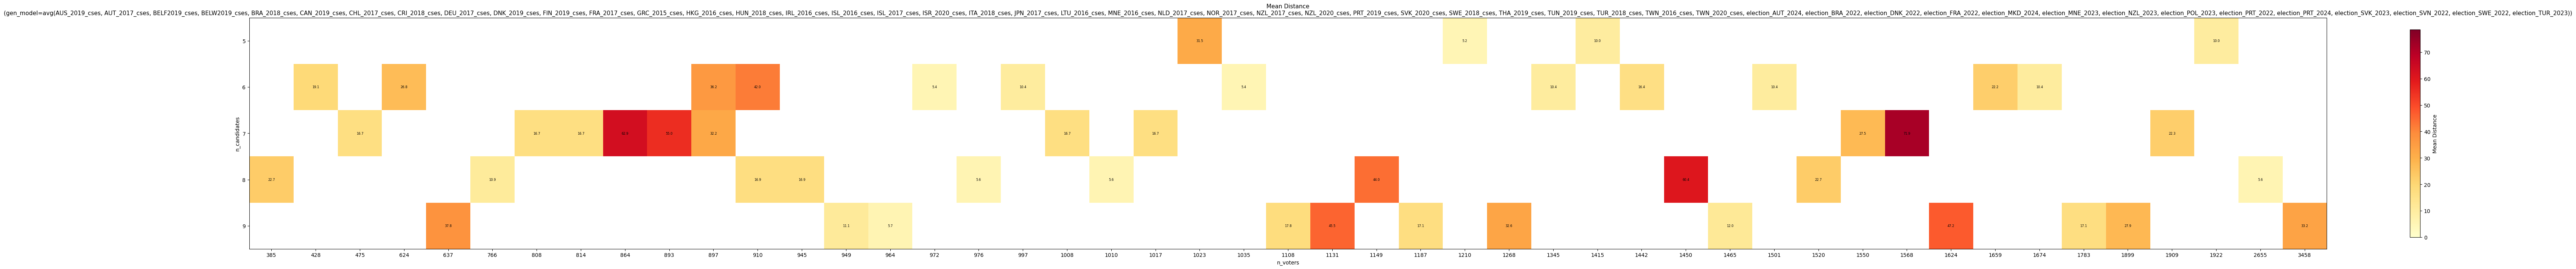

<Axes: title={'center': 'Mean Distance\n(gen_model=avg(AUS_2019_cses, AUT_2017_cses, BELF2019_cses, BELW2019_cses, BRA_2018_cses, CAN_2019_cses, CHL_2017_cses, CRI_2018_cses, DEU_2017_cses, DNK_2019_cses, FIN_2019_cses, FRA_2017_cses, GRC_2015_cses, HKG_2016_cses, HUN_2018_cses, IRL_2016_cses, ISL_2016_cses, ISL_2017_cses, ISR_2020_cses, ITA_2018_cses, JPN_2017_cses, LTU_2016_cses, MNE_2016_cses, NLD_2017_cses, NOR_2017_cses, NZL_2017_cses, NZL_2020_cses, PRT_2019_cses, SVK_2020_cses, SWE_2018_cses, THA_2019_cses, TUN_2019_cses, TUR_2018_cses, TWN_2016_cses, TWN_2020_cses, election_AUT_2024, election_BRA_2022, election_DNK_2022, election_FRA_2022, election_MKD_2024, election_MNE_2023, election_NZL_2023, election_POL_2023, election_PRT_2022, election_PRT_2024, election_SVK_2023, election_SVN_2022, election_SWE_2022, election_TUR_2023))'}, xlabel='n_voters', ylabel='n_candidates'>

In [5]:
# Rows = n_candidates groups, columns = n_voters (one per election)
total_result.plot_metric_heatmap(row_param="n_candidates", col_param="n_voters")

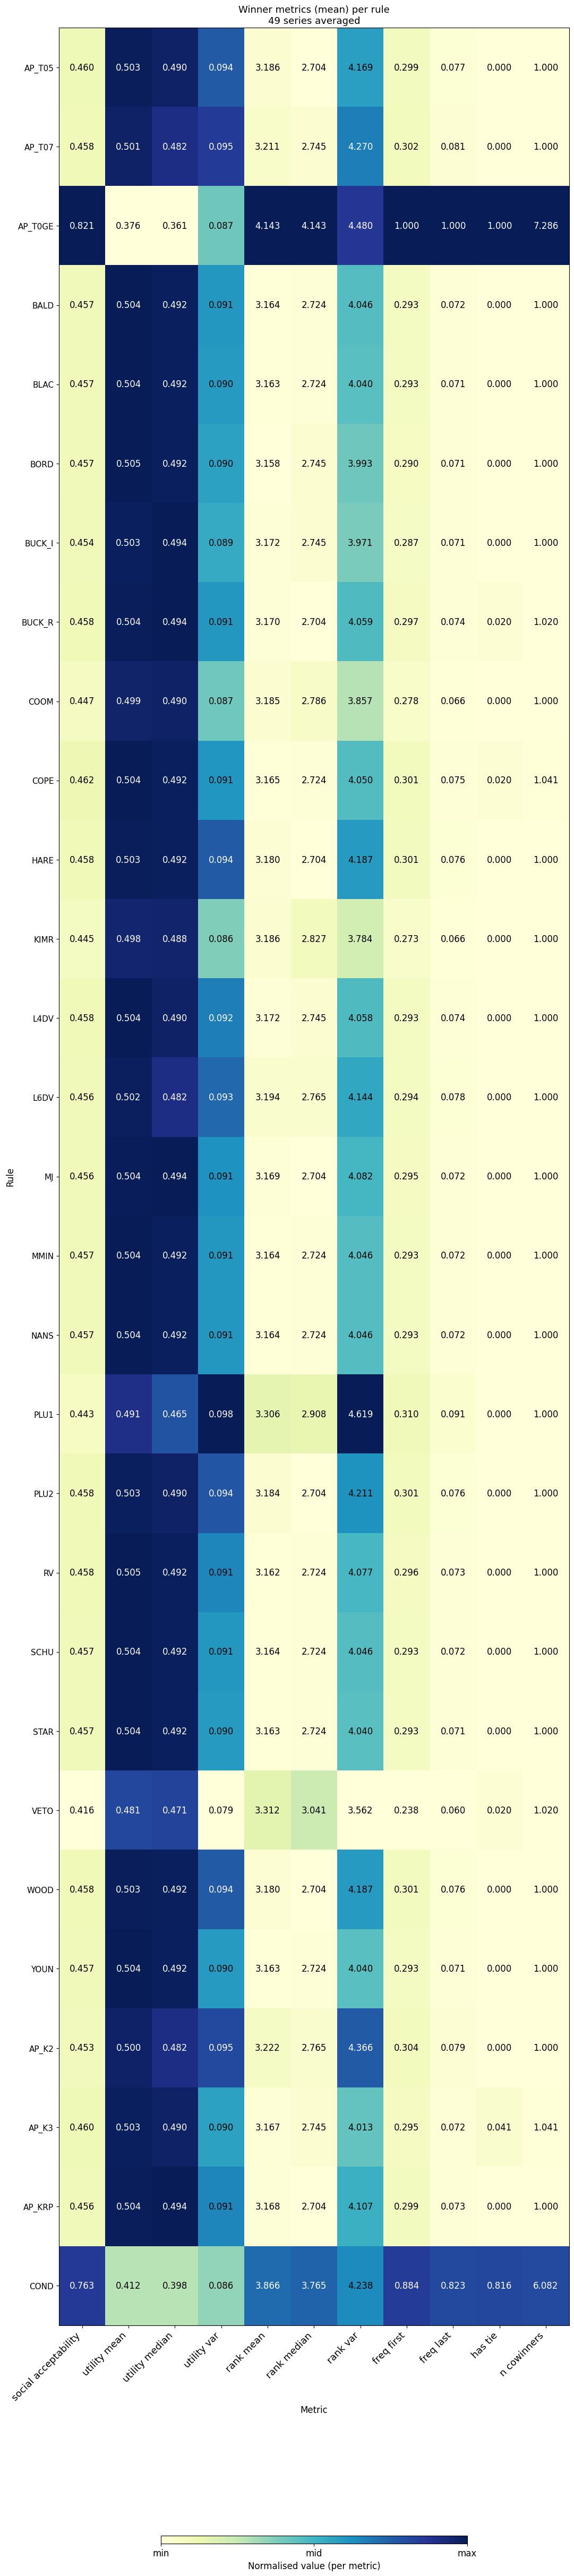

<Axes: title={'center': 'Winner metrics (mean) per rule\n49 series averaged'}, xlabel='Metric', ylabel='Rule'>

In [6]:
total_result.plot_metrics_rules_matrix()

## 4 — Per-candidate-count analysis

For each group: distance matrix heatmap, 2-D & 3-D MDS projections, metrics matrix.


── 5 candidates (4 elections) ──────────────────


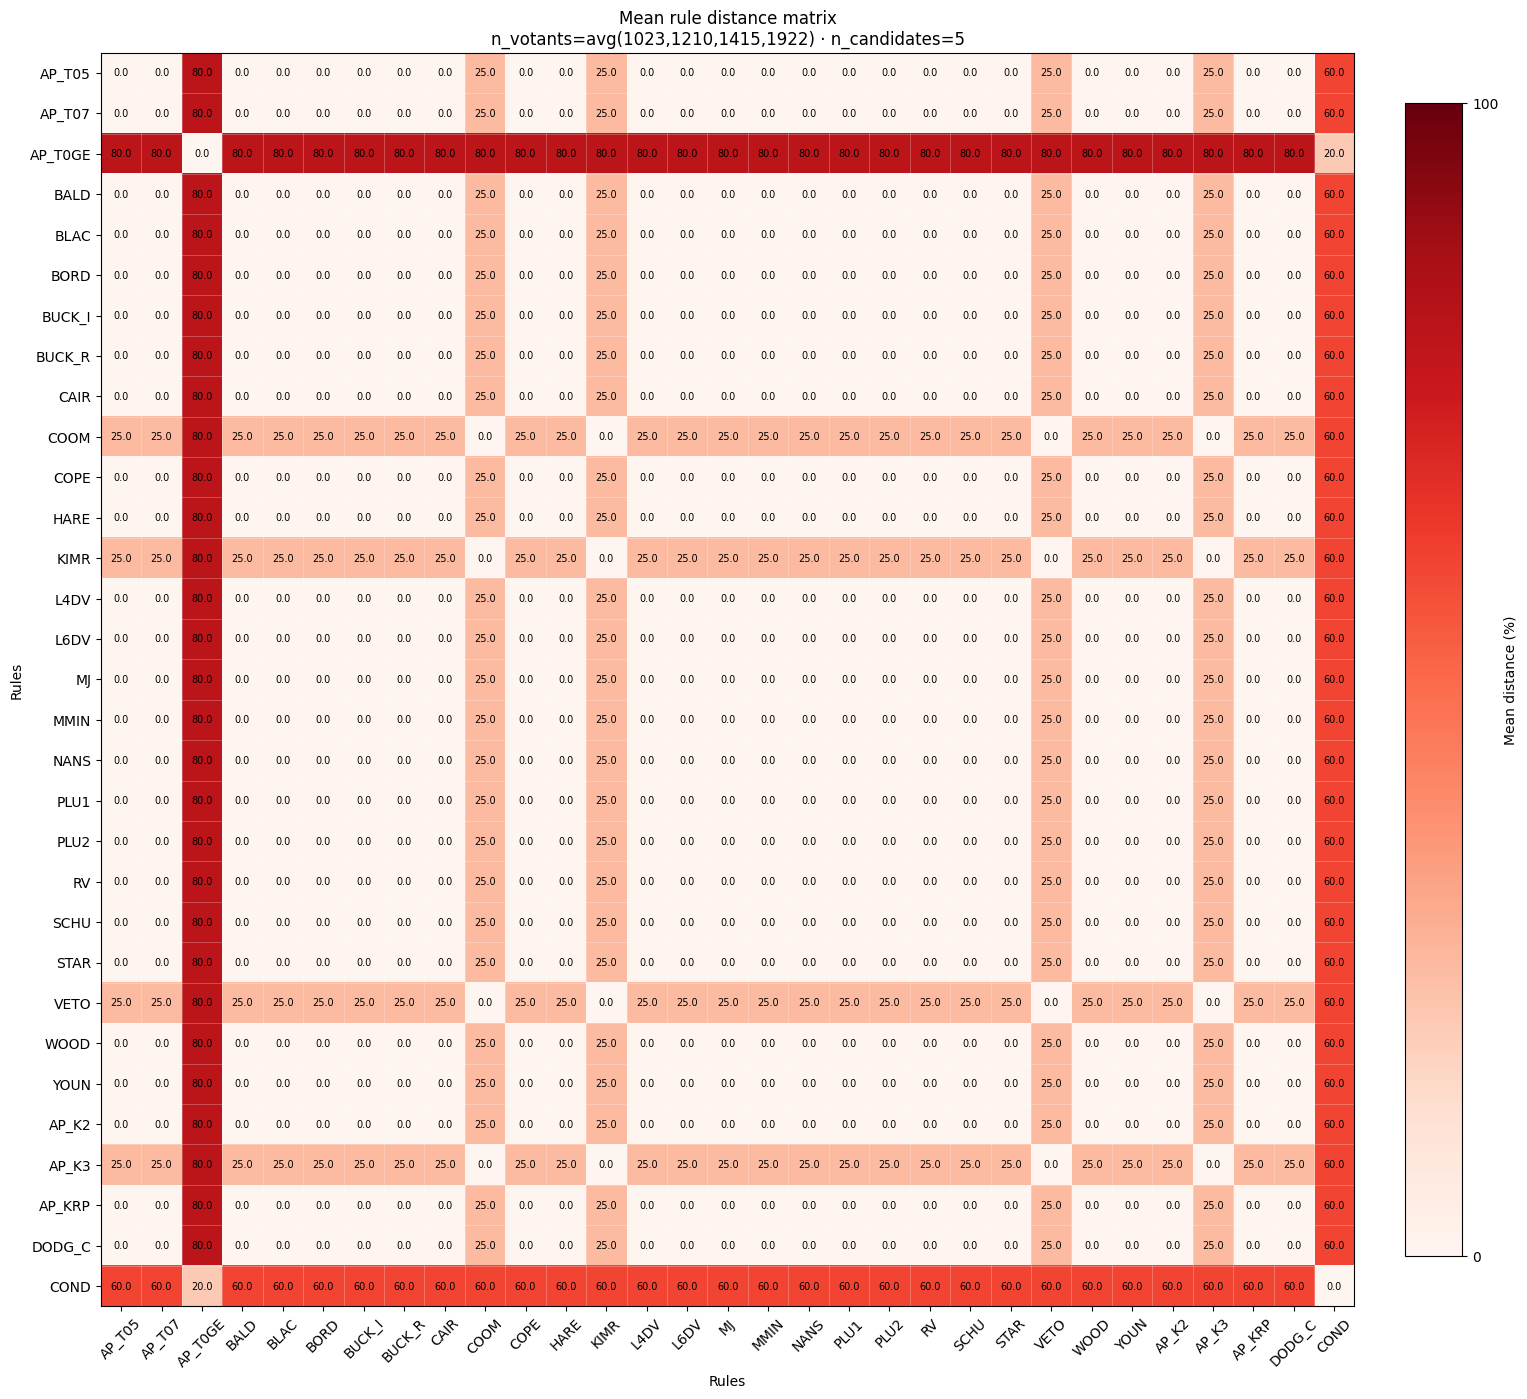

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


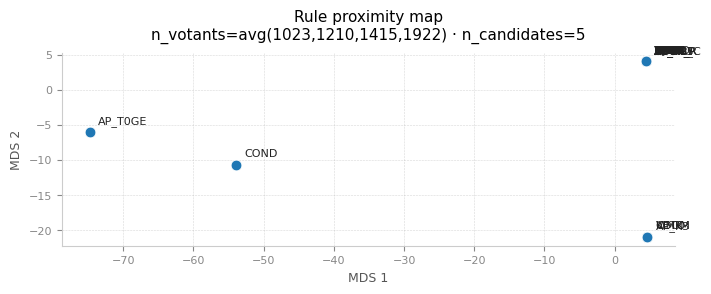

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


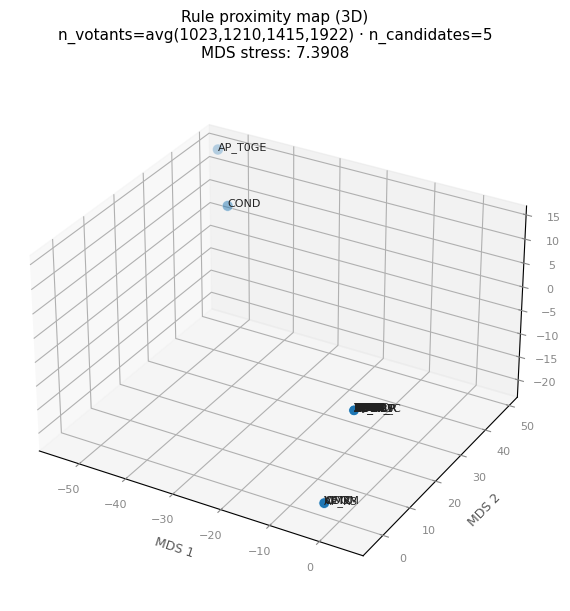

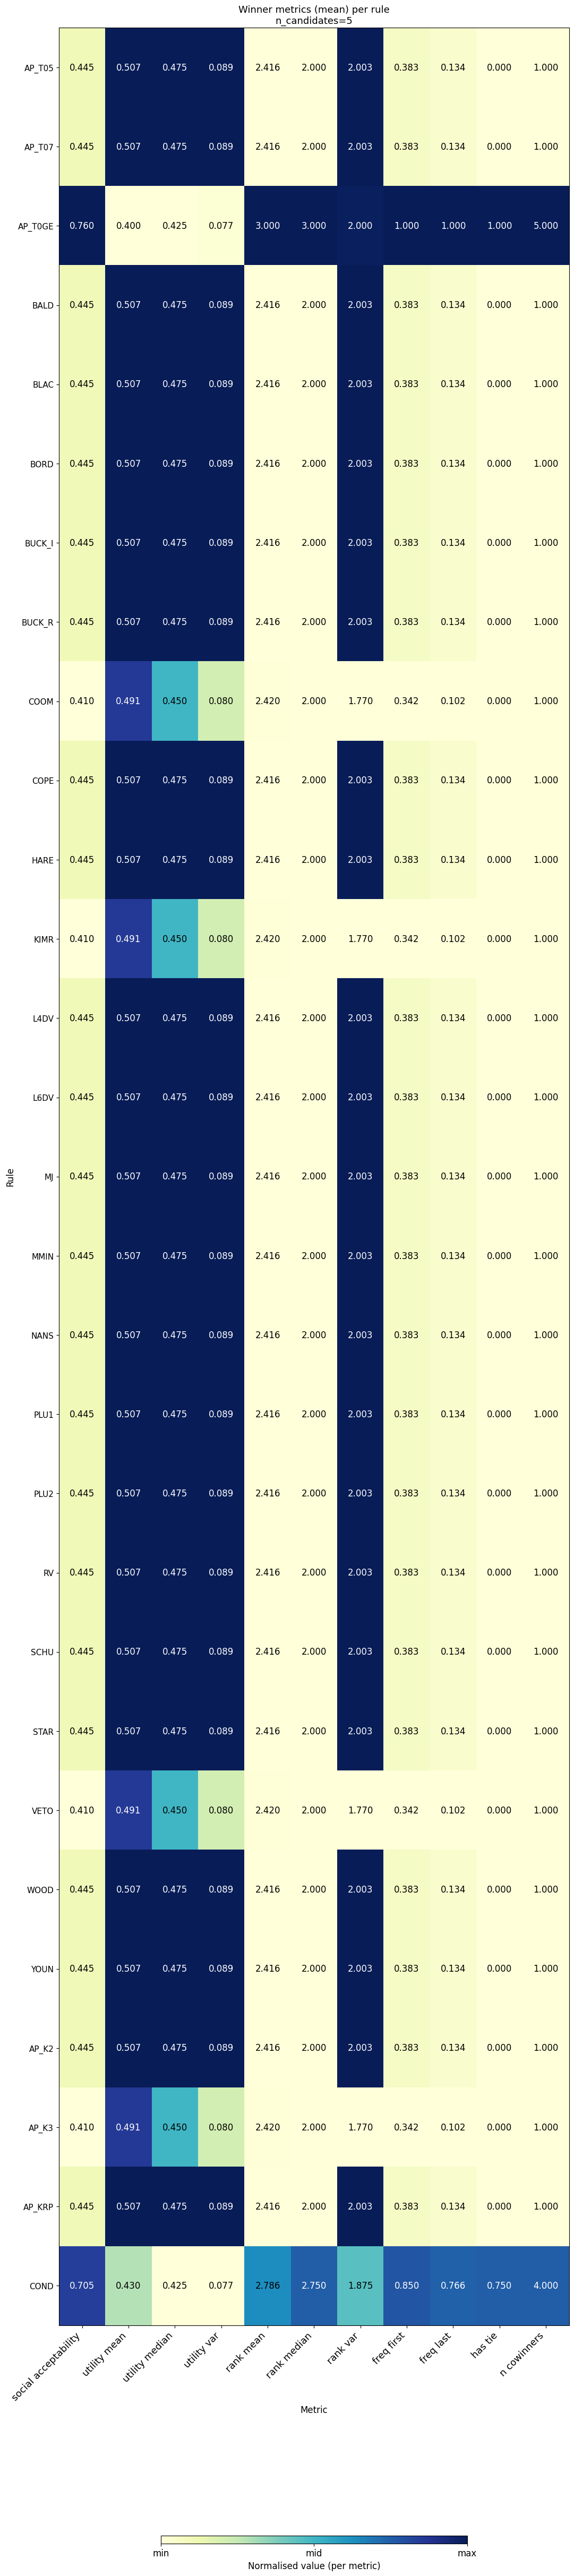


── 6 candidates (12 elections) ──────────────────


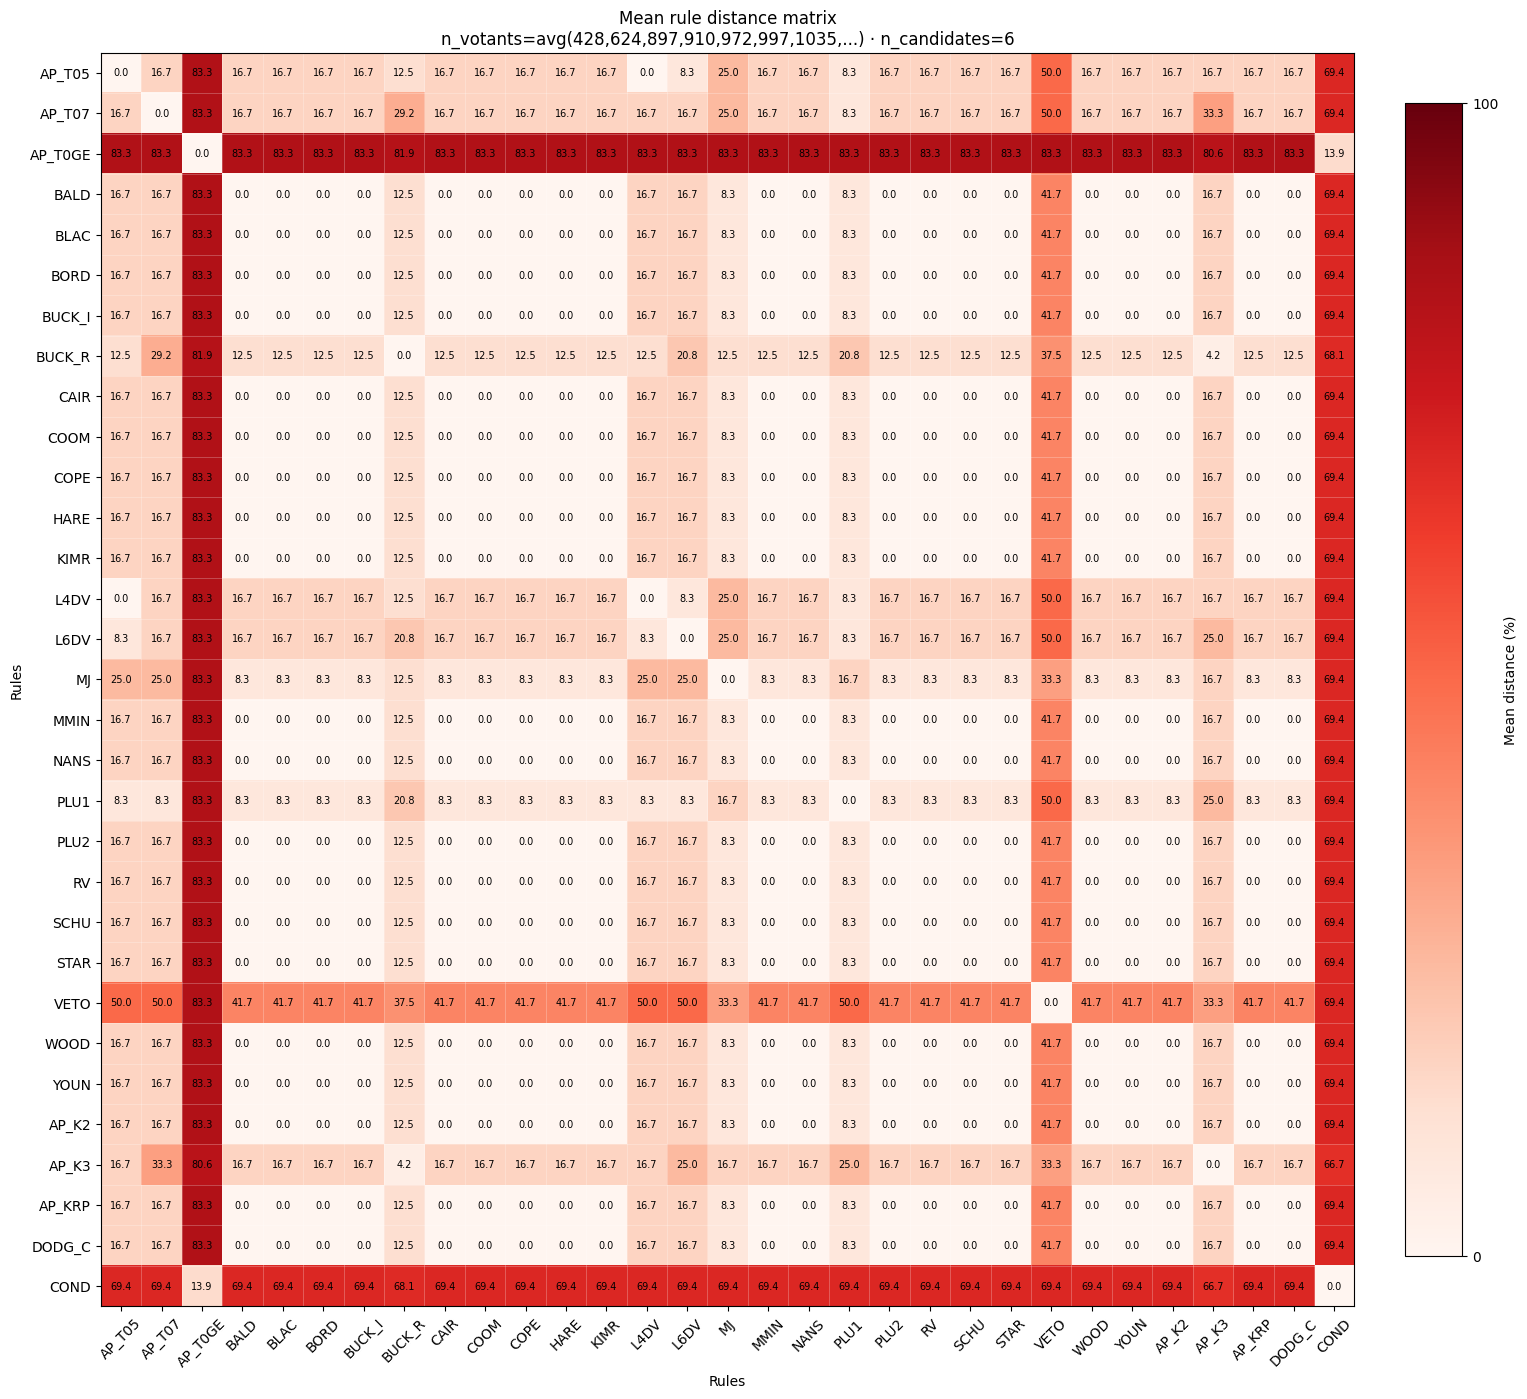

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


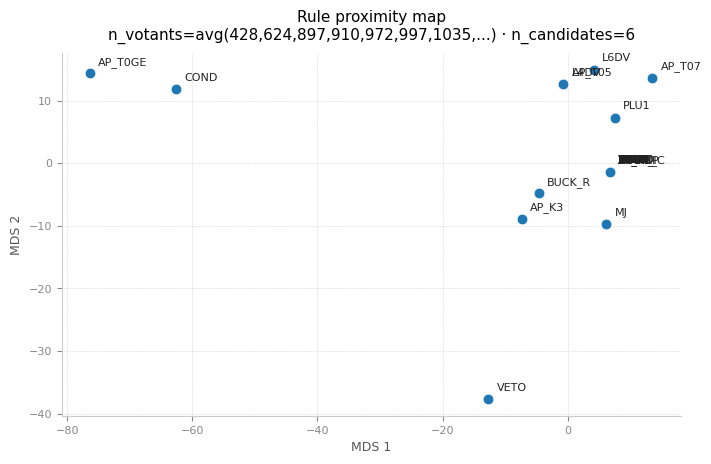

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


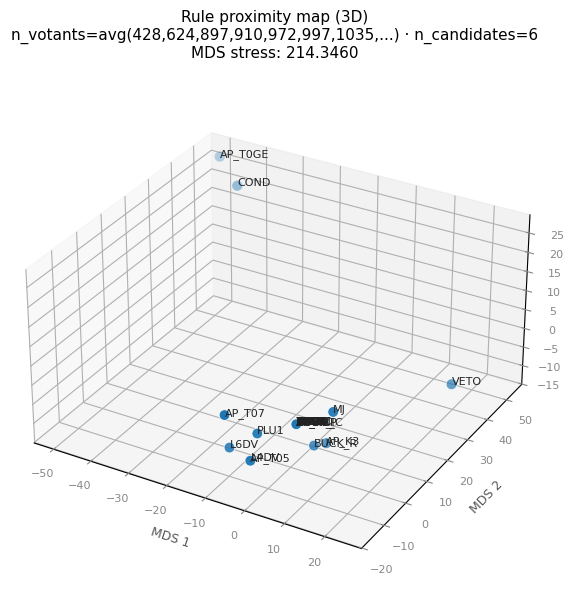

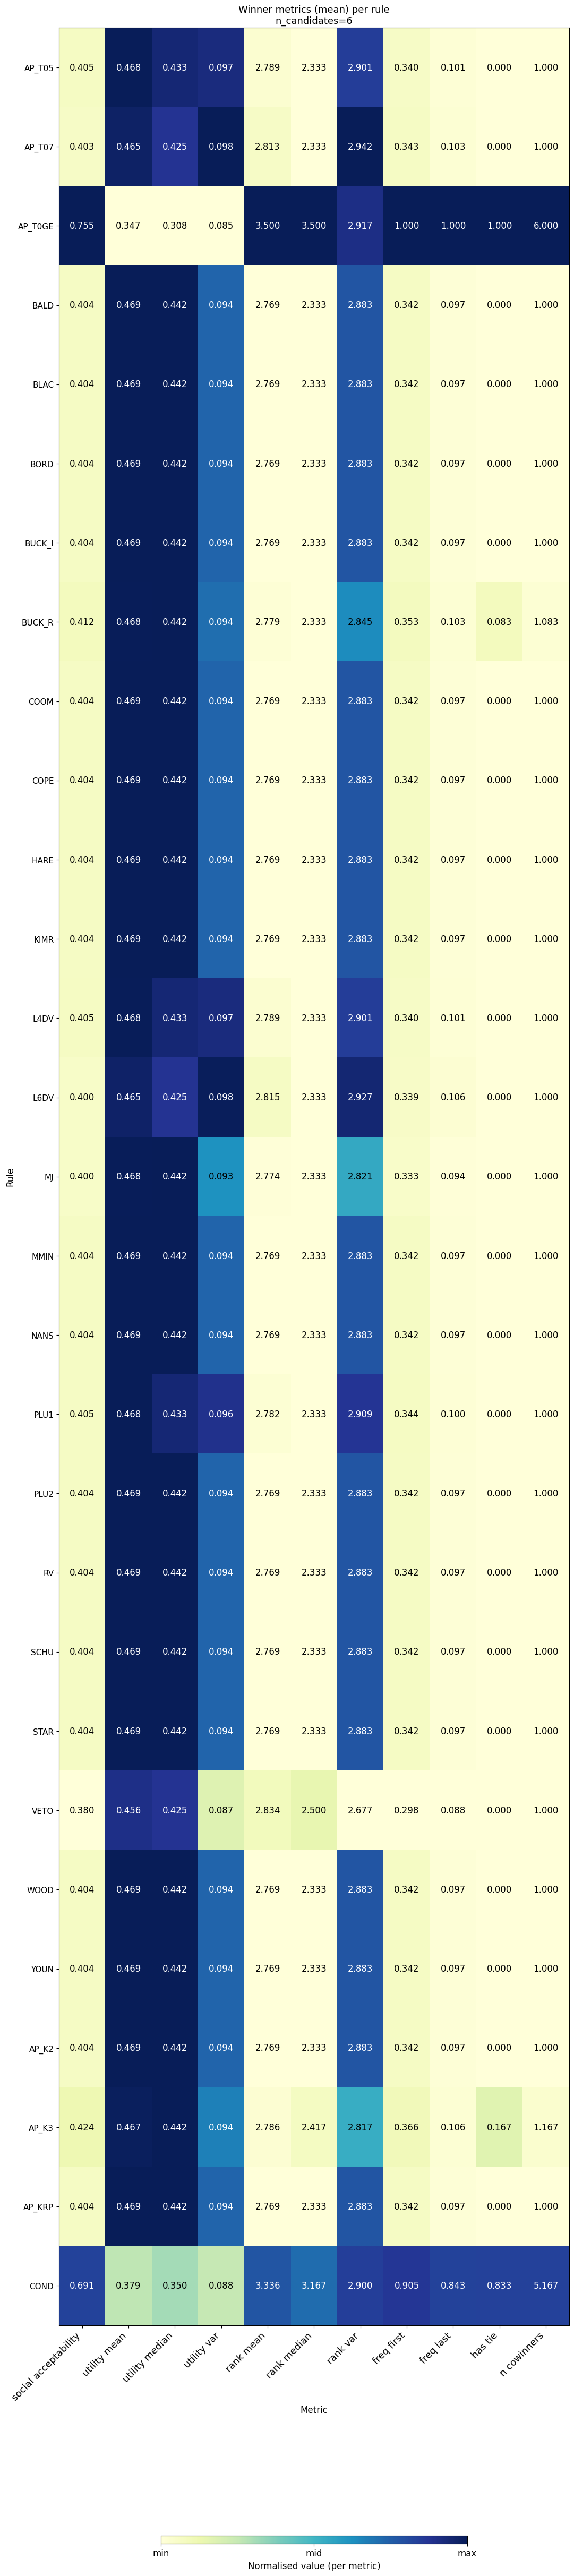


── 7 candidates (11 elections) ──────────────────


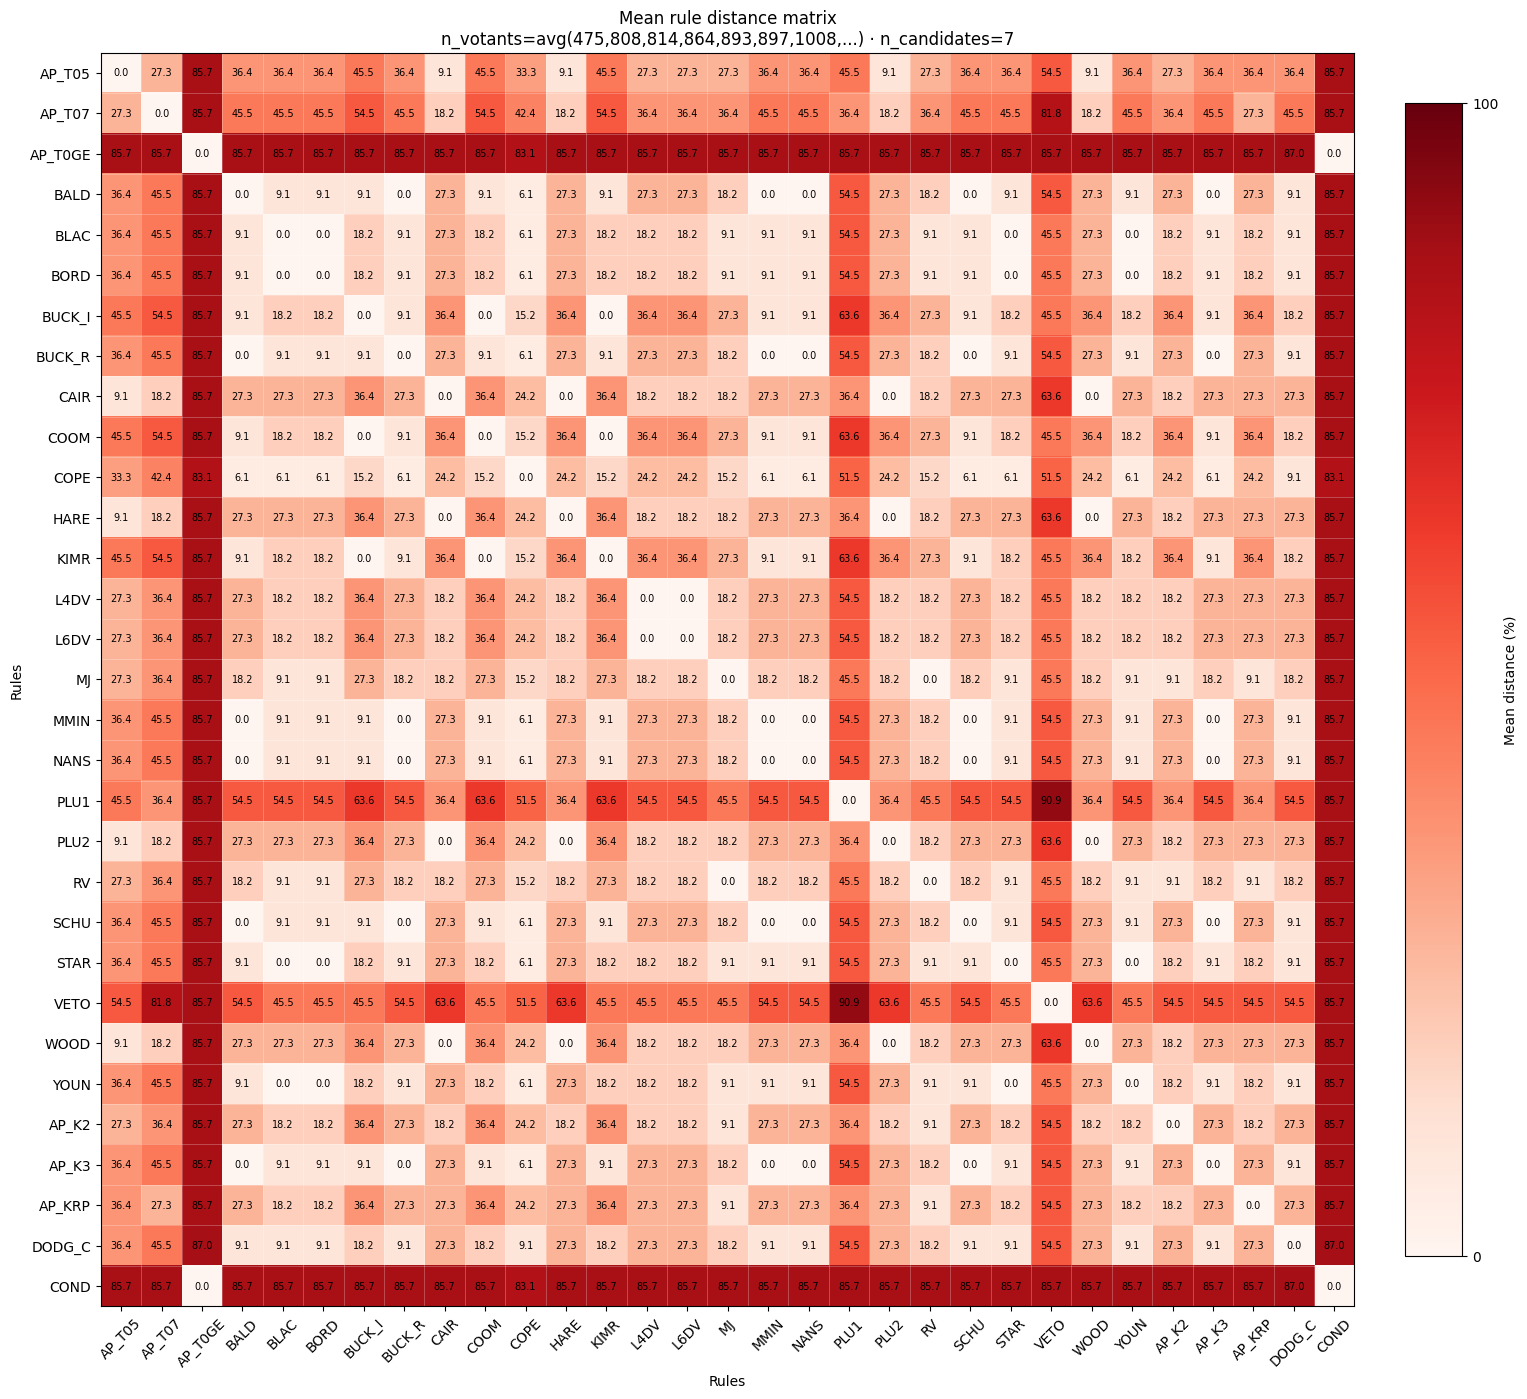

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


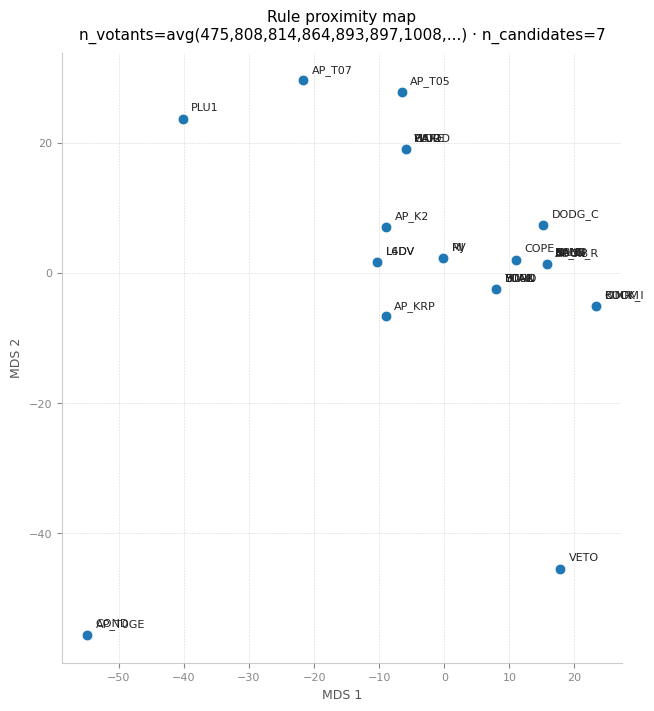

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


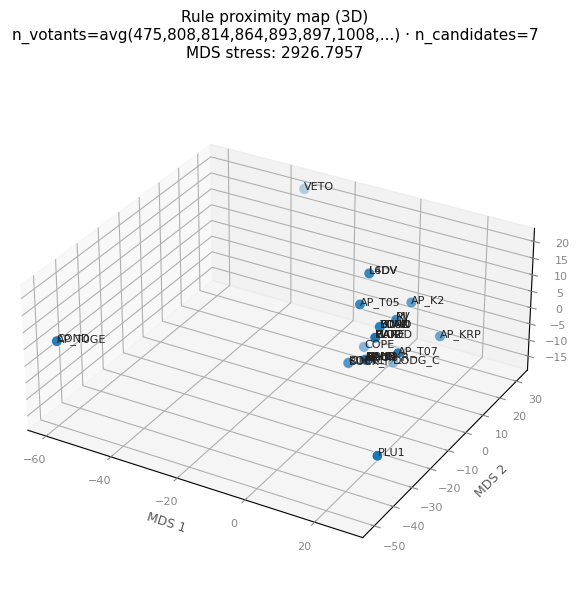

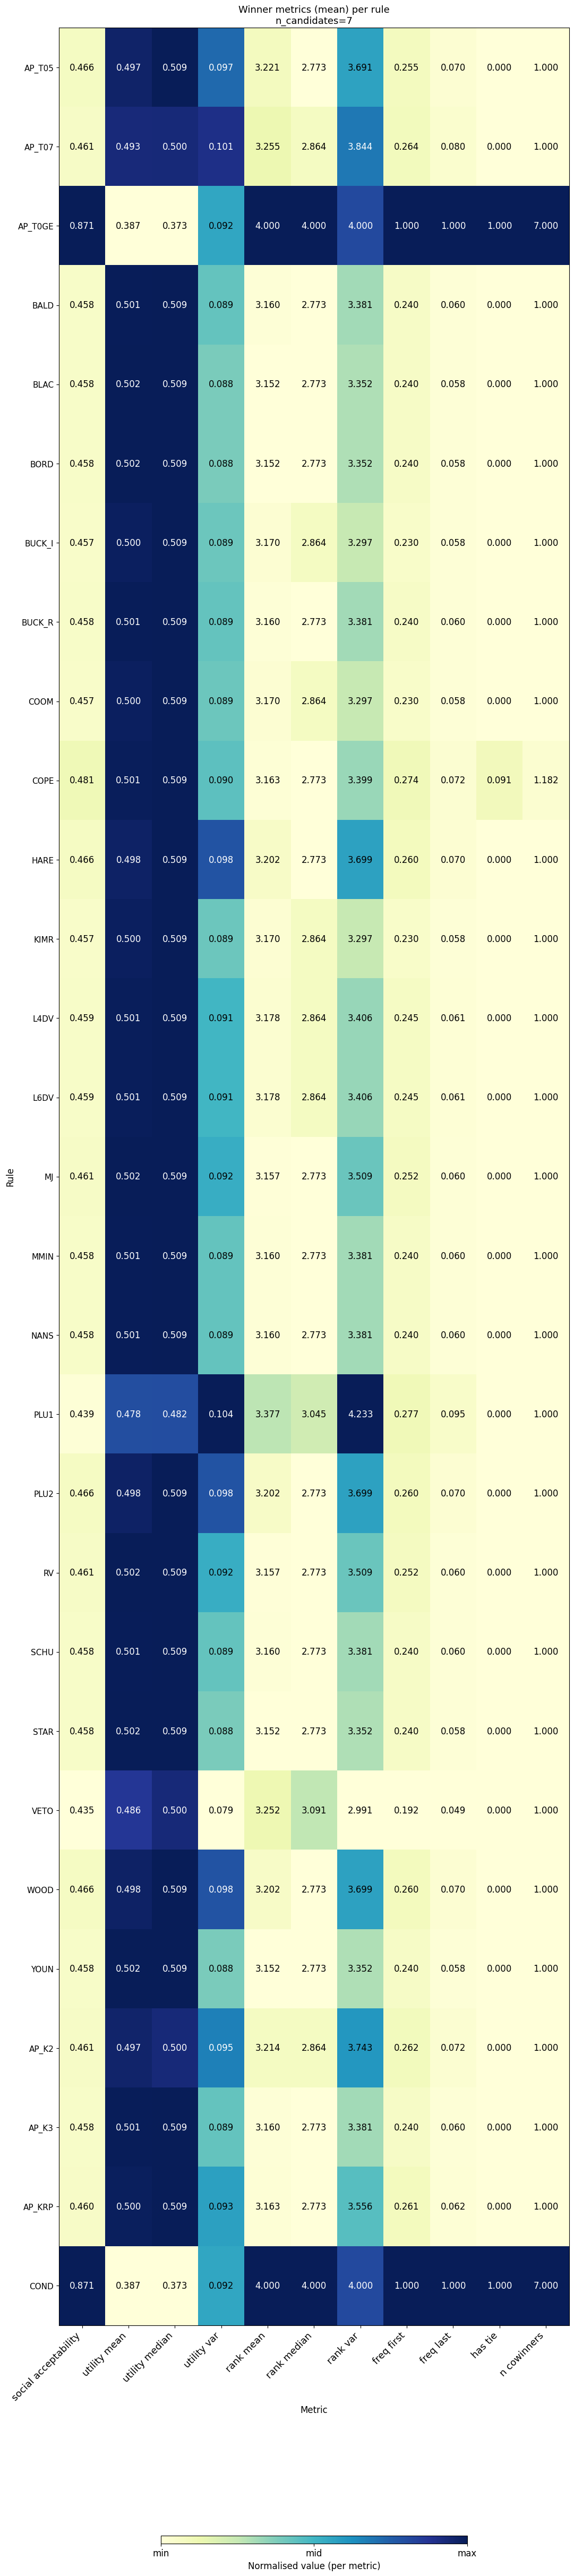


── 8 candidates (10 elections) ──────────────────


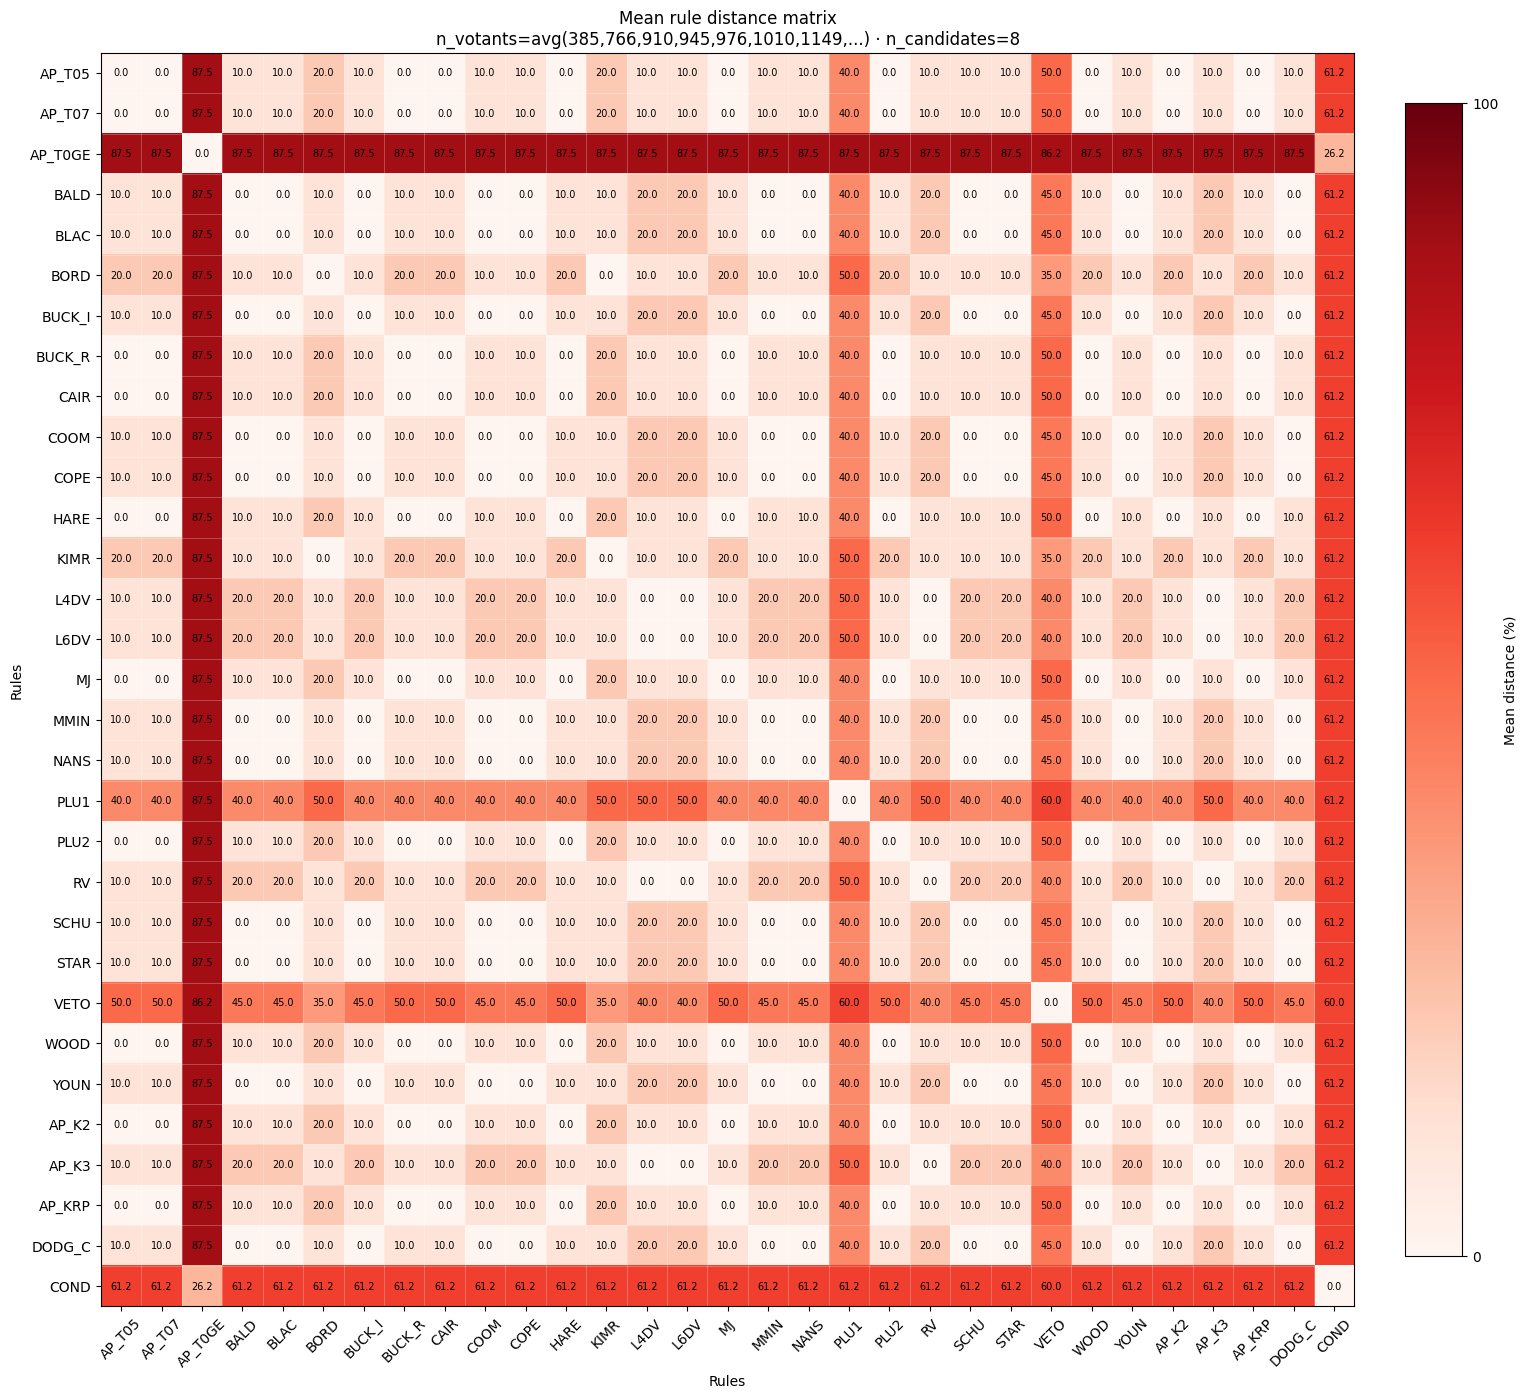

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


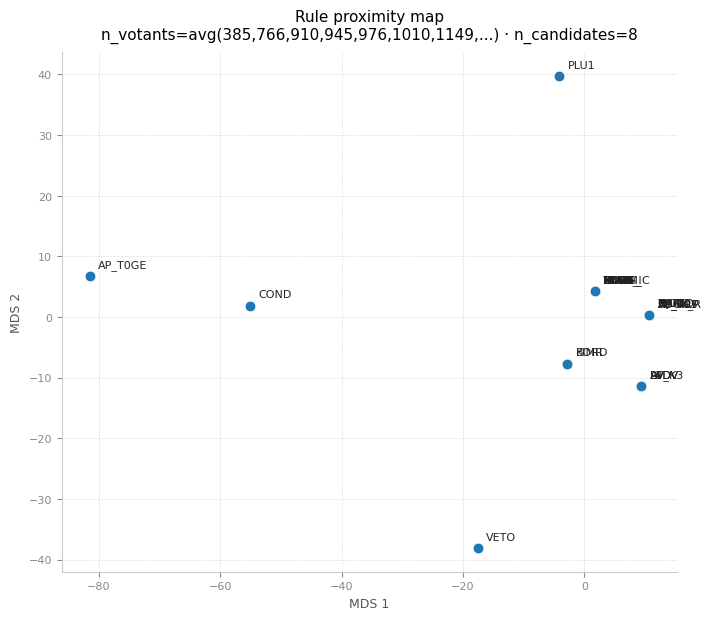

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


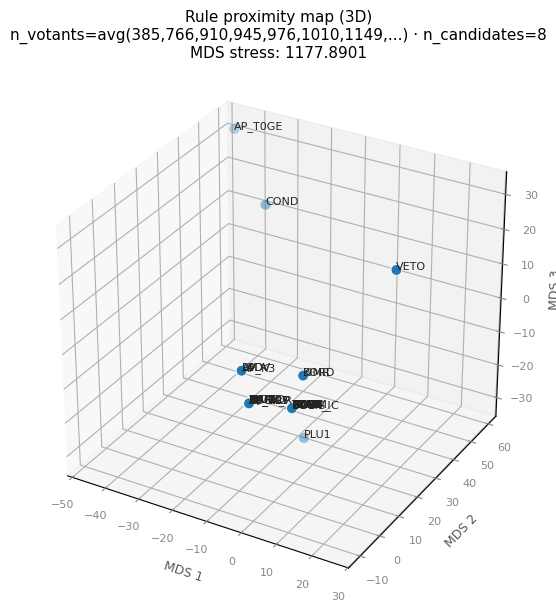

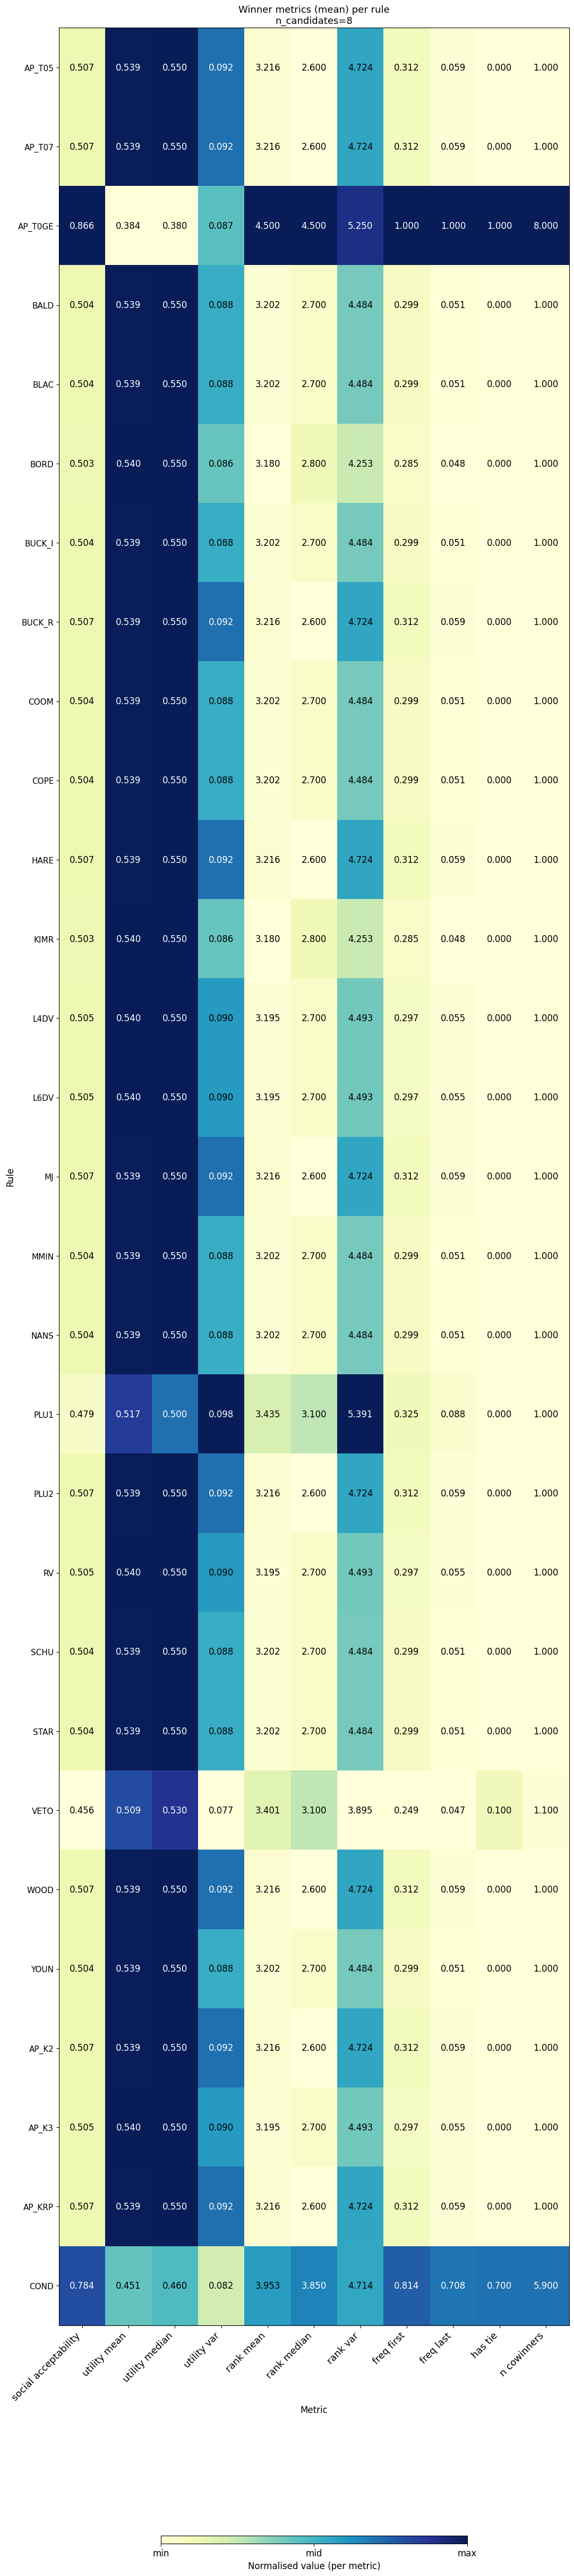


── 9 candidates (12 elections) ──────────────────


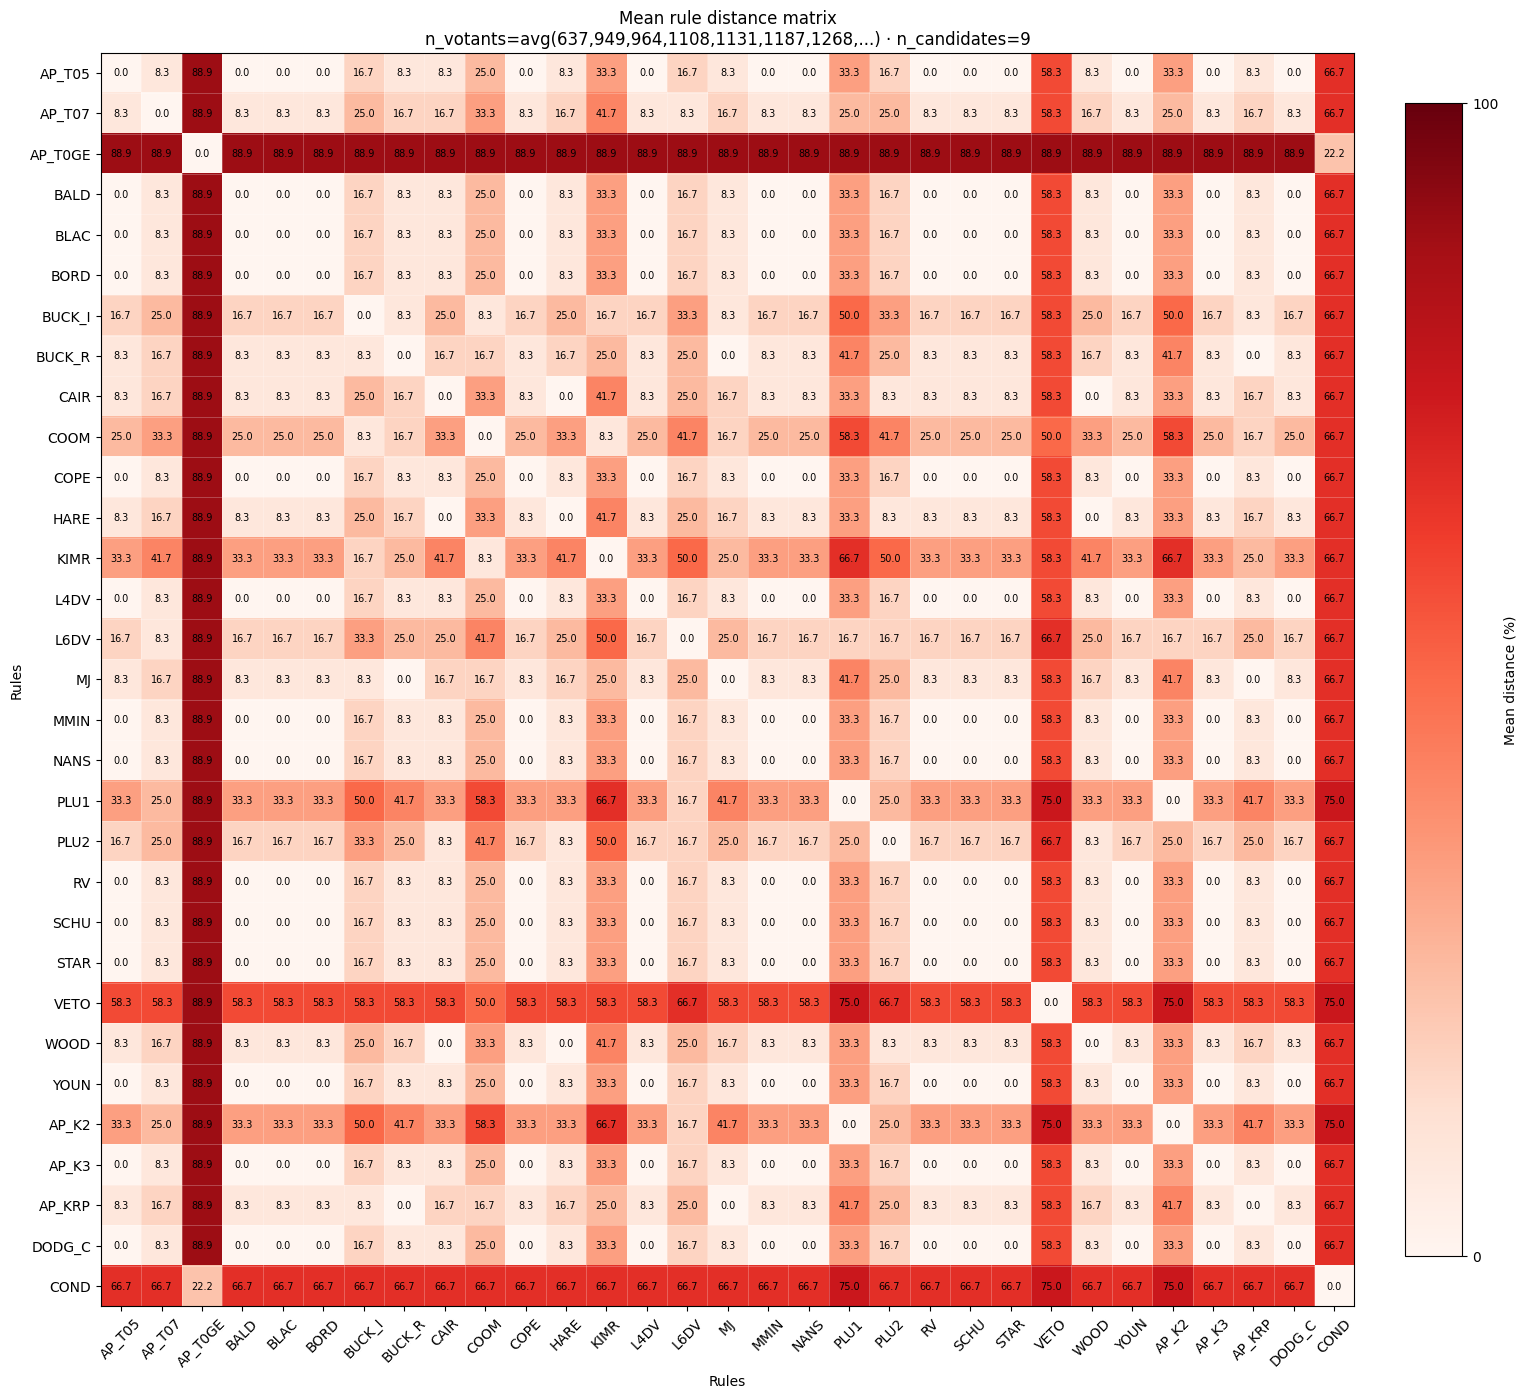

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


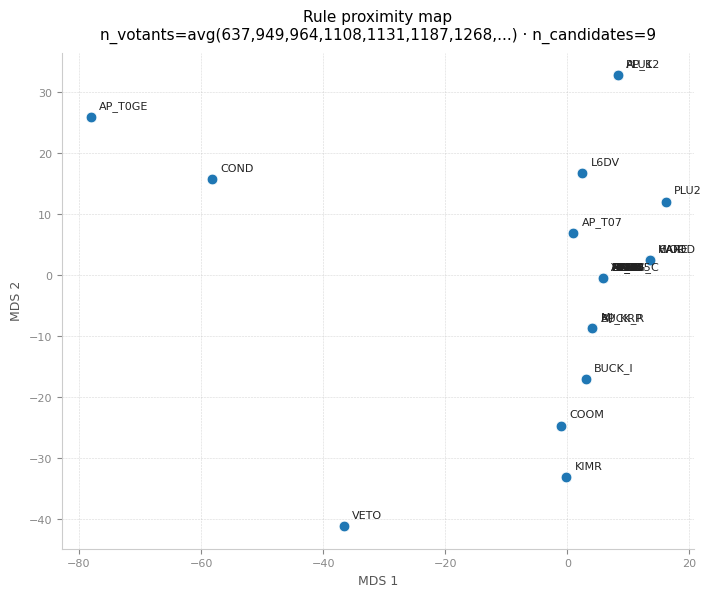

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


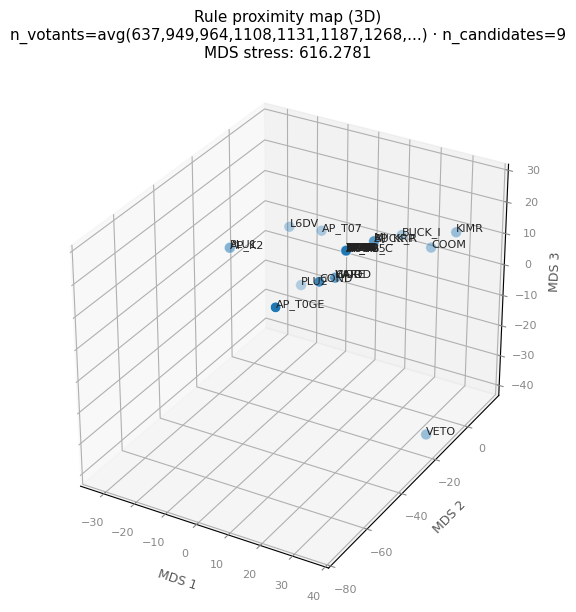

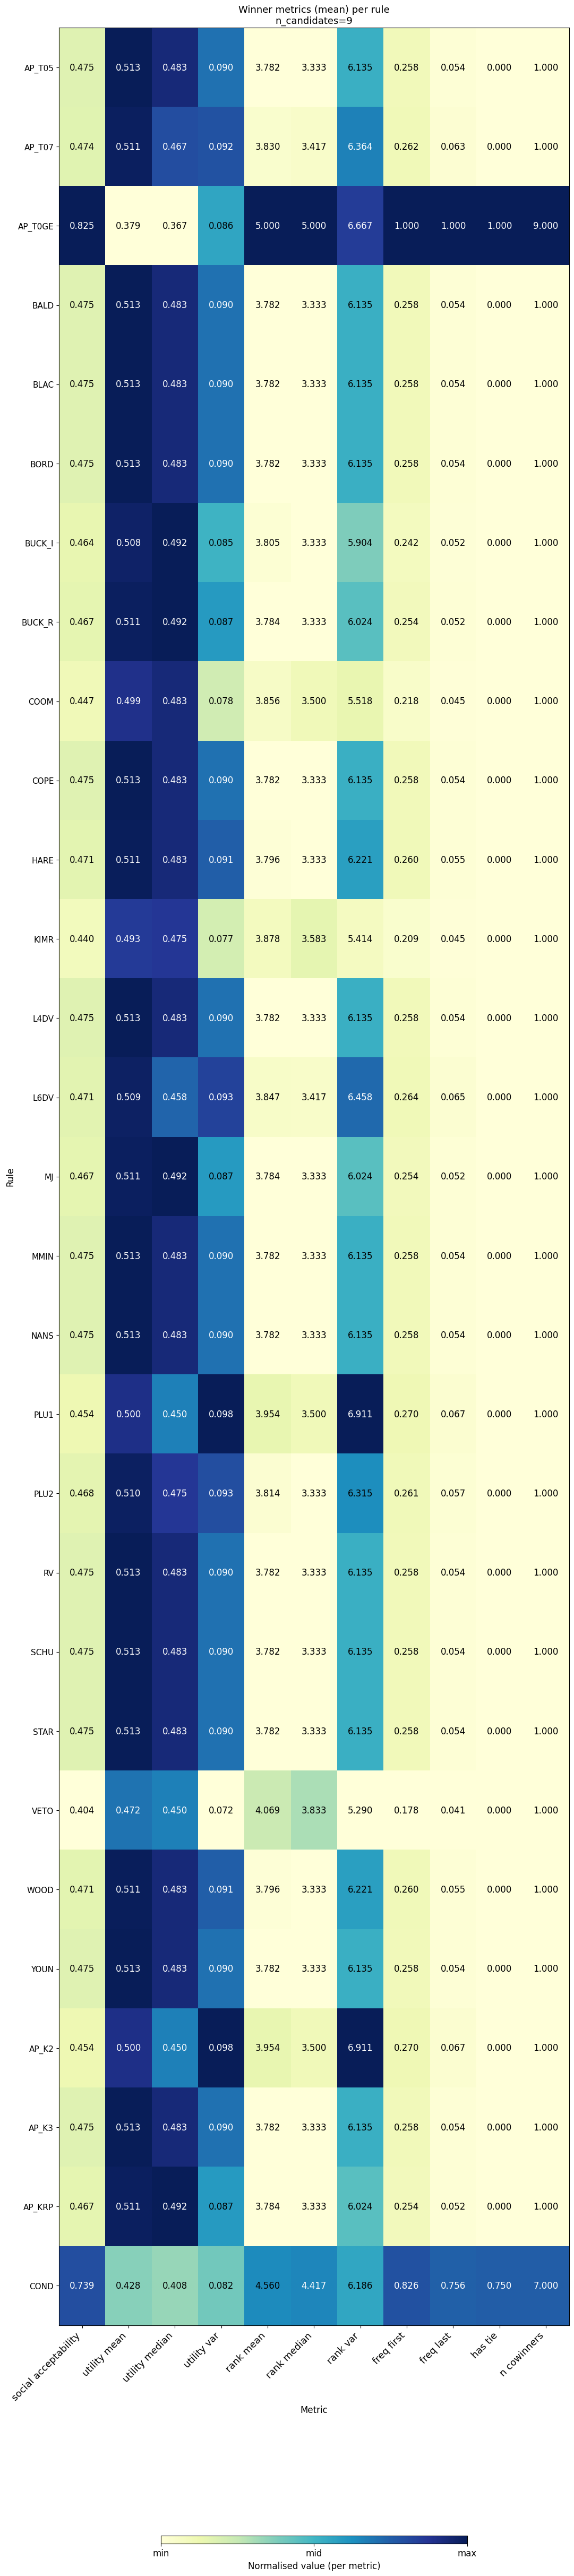

In [7]:
base_path = Path(OUTPUT_BASE)

unique_n_c = sorted({e["n_candidates"] for e in selected})

for n_c in unique_n_c:
    sub = total_result.filter(n_candidates=n_c)
    if sub.series_count == 0:
        continue

    out_dir = base_path / f"c{n_c}"
    out_csv = out_dir / "csv"

    print(f"\n── {n_c} candidates ({sub.series_count} elections) ──────────────────")

    sub.plot_mean_distance_matrix(save_path=str(out_dir / f"c{n_c}_distance.png"))
    sub.export_mean_distance_matrix_csv(save_path=str(out_csv / f"c{n_c}_distance.csv"))
    sub.plot_rules_2d(save_path=str(out_dir / f"c{n_c}_rules_2d.png"))
    sub.plot_rules_3d(save_path=str(out_dir / f"c{n_c}_rules_3d.png"))
    if COMPUTE_METRICS:
        sub.plot_metrics_rules_matrix(save_path=str(out_dir / f"c{n_c}_metrics.png"))
        sub.export_metrics_rules_matrix_csv(save_path=str(out_csv / f"c{n_c}_metrics.csv"))

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


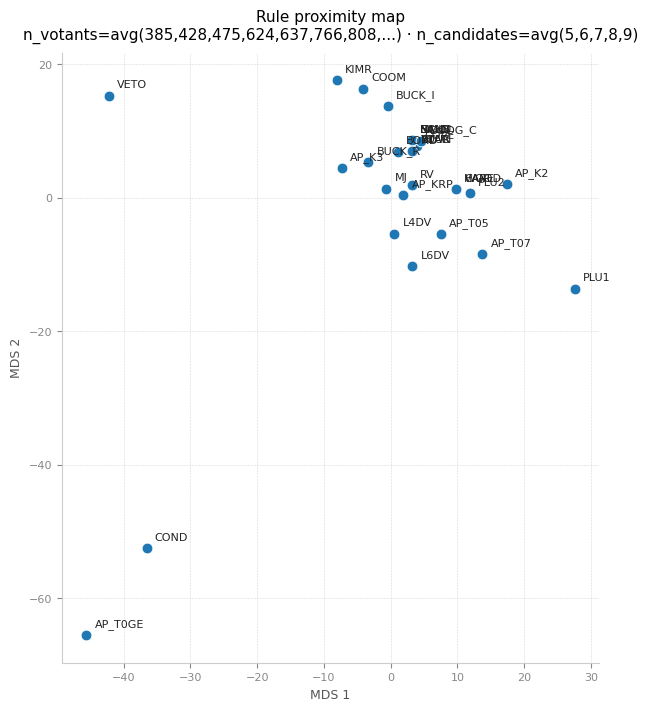

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


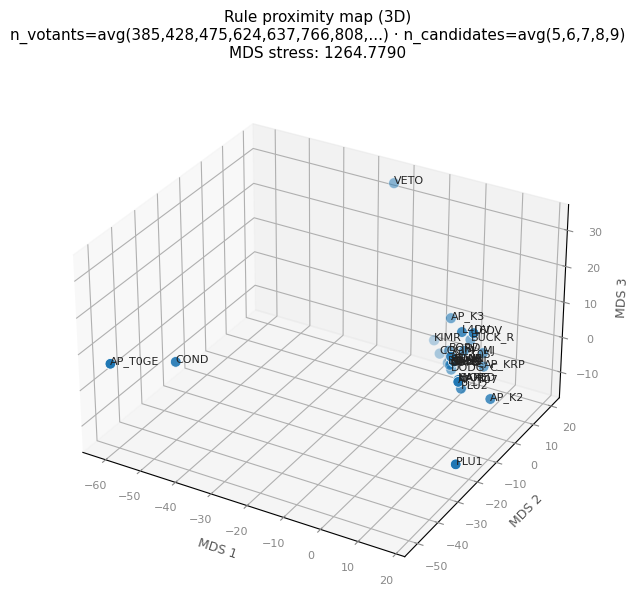

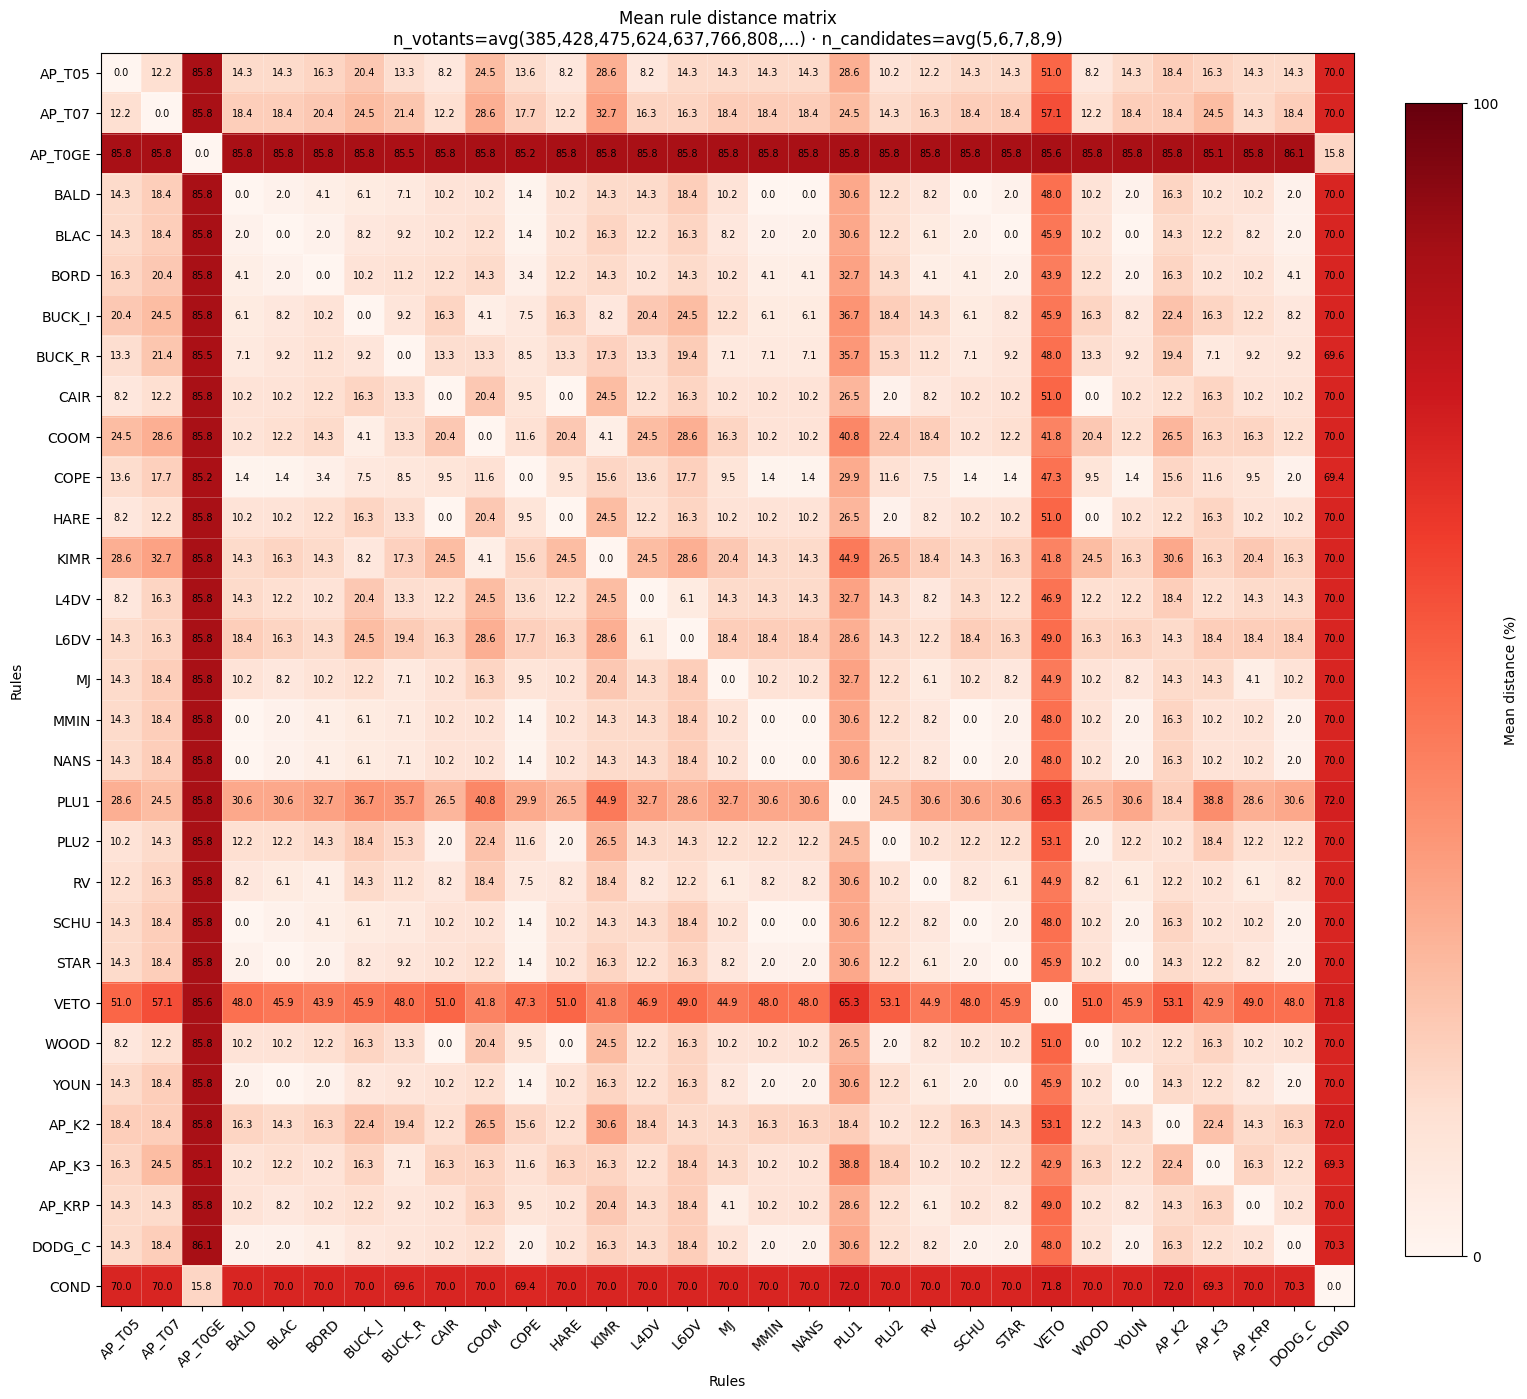

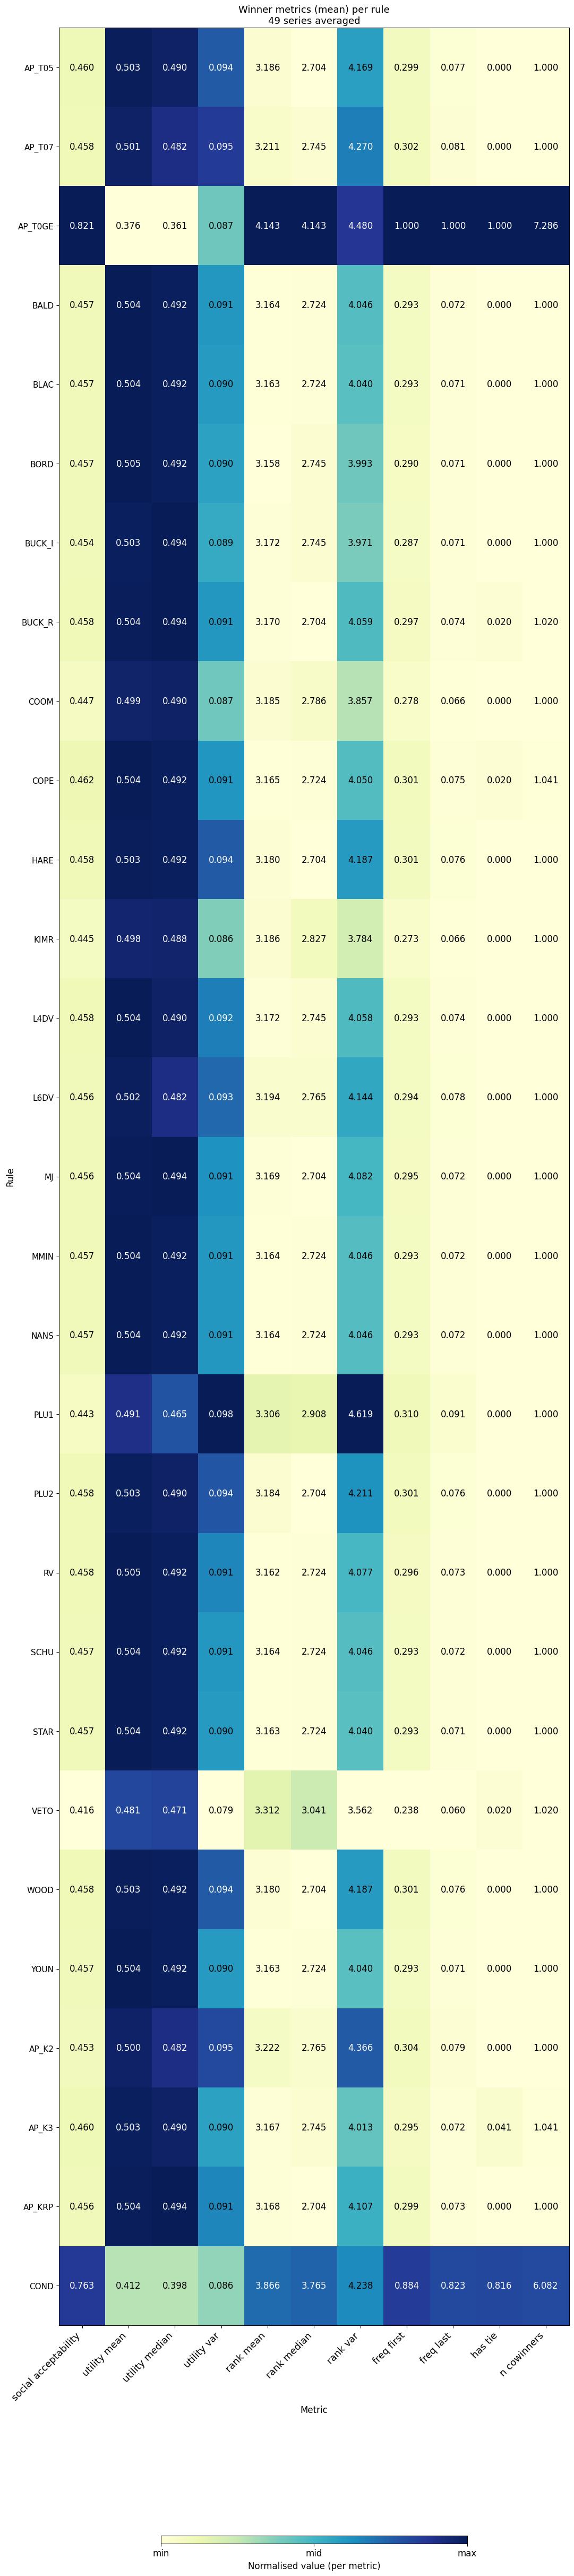

<Axes: title={'center': 'Winner metrics (mean) per rule\n49 series averaged'}, xlabel='Metric', ylabel='Rule'>

In [8]:
total_result.plot_rules_2d(save_path=str(base_path / "rules_2d.png"))
total_result.plot_rules_3d(save_path=str(base_path / "rules_3d.png"))
total_result.export_mean_distance_matrix_csv(save_path=str(base_path / "mean_distance.csv"))
total_result.export_metrics_rules_matrix_csv(save_path=str(base_path / "metrics.csv"))
total_result.plot_mean_distance_matrix(save_path=str(base_path / "mean_distance.png"))
total_result.plot_metrics_rules_matrix(save_path=str(base_path / "metrics.png"))

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


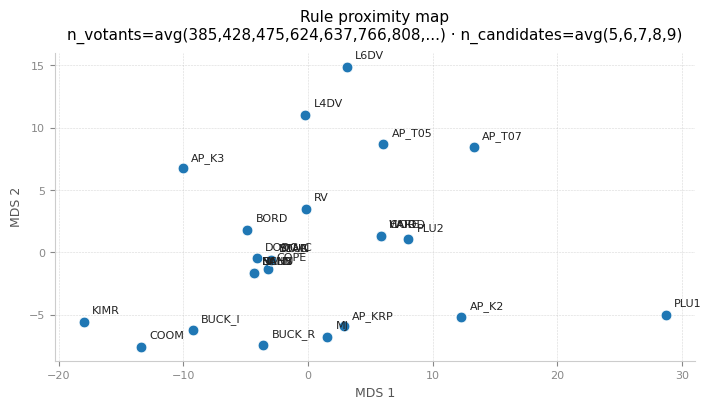

{'HUN_2018_cses': 2, 'TWN_2016_cses': 1, 'TWN_2020_cses': 1, 'AUS_2019_cses': 1, 'CAN_2019_cses': 2, 'HKG_2016_cses': 3, 'TUN_2019_cses': 2, 'CRI_2018_cses': 3, 'TUR_2018_cses': 1, 'election_MKD_2024': 1, 'AUT_2017_cses': 1, 'PRT_2019_cses': 1, 'election_TUR_2023': 1, 'JPN_2017_cses': 1, 'FRA_2017_cses': 2, 'ITA_2018_cses': 1, 'BELW2019_cses': 2, 'MNE_2016_cses': 1, 'IRL_2016_cses': 1, 'BELF2019_cses': 3, 'SVK_2020_cses': 3, 'election_NZL_2023': 2, 'election_SVK_2023': 2, 'ISL_2016_cses': 2, 'election_FRA_2022': 2, 'election_AUT_2024': 5, 'DEU_2017_cses': 2, 'THA_2019_cses': 2, 'election_SVN_2022': 1, 'ISR_2020_cses': 1, 'GRC_2015_cses': 2, 'NZL_2020_cses': 1, 'LTU_2016_cses': 1, 'NZL_2017_cses': 2, 'election_POL_2023': 3, 'ISL_2017_cses': 2, 'election_SWE_2022': 1, 'BRA_2018_cses': 2, 'election_PRT_2024': 1, 'election_PRT_2022': 1, 'DNK_2019_cses': 2, 'CHL_2017_cses': 2, 'election_MNE_2023': 1, 'FIN_2019_cses': 2, 'election_DNK_2022': 1, 'NLD_2017_cses': 3, 'NOR_2017_cses': 2, 'electi

count
1        21
2        21
3         6
5         1
Name: count, dtype: int64

In [ ]:
import pandas as pd

filtered_rules = [r for r in RULE_CODES if r != "AP_T0GE" and r != "VETO" and r != "COND"]
total_filtered = total_result.filter_rules(filtered_rules)

total_filtered.plot_rules_2d(save_path=str(base_path / "rules_2d_no_APT0GE.png"))

to_output = dict()

# 0.5 = 0
for c in [5, 6, 7, 8, 9]:
    filter_f = total_filtered.filter(n_candidates=c)
    voters = filter_f.voter_counts

    for v in voters:
        fcv = filter_f.filter(n_voters=v)
        name = fcv.gen_models[0]
        # print(f"Name : {name}  n_candidates={c}  n_voters={v}")

        m = fcv.mean_distance_matrix_frame()
        m = m.drop_duplicates()
        to_output[name] = len(m)

print(to_output)

df = pd.DataFrame(list(to_output.items()), columns=pd.Index(["name", "count"]))
df.to_csv(base_path / "elected_candidates_count.csv", index=False)

df.describe()

# group by count and give how many elections have x number of elected candidates
df.value_counts(subset=["count"])

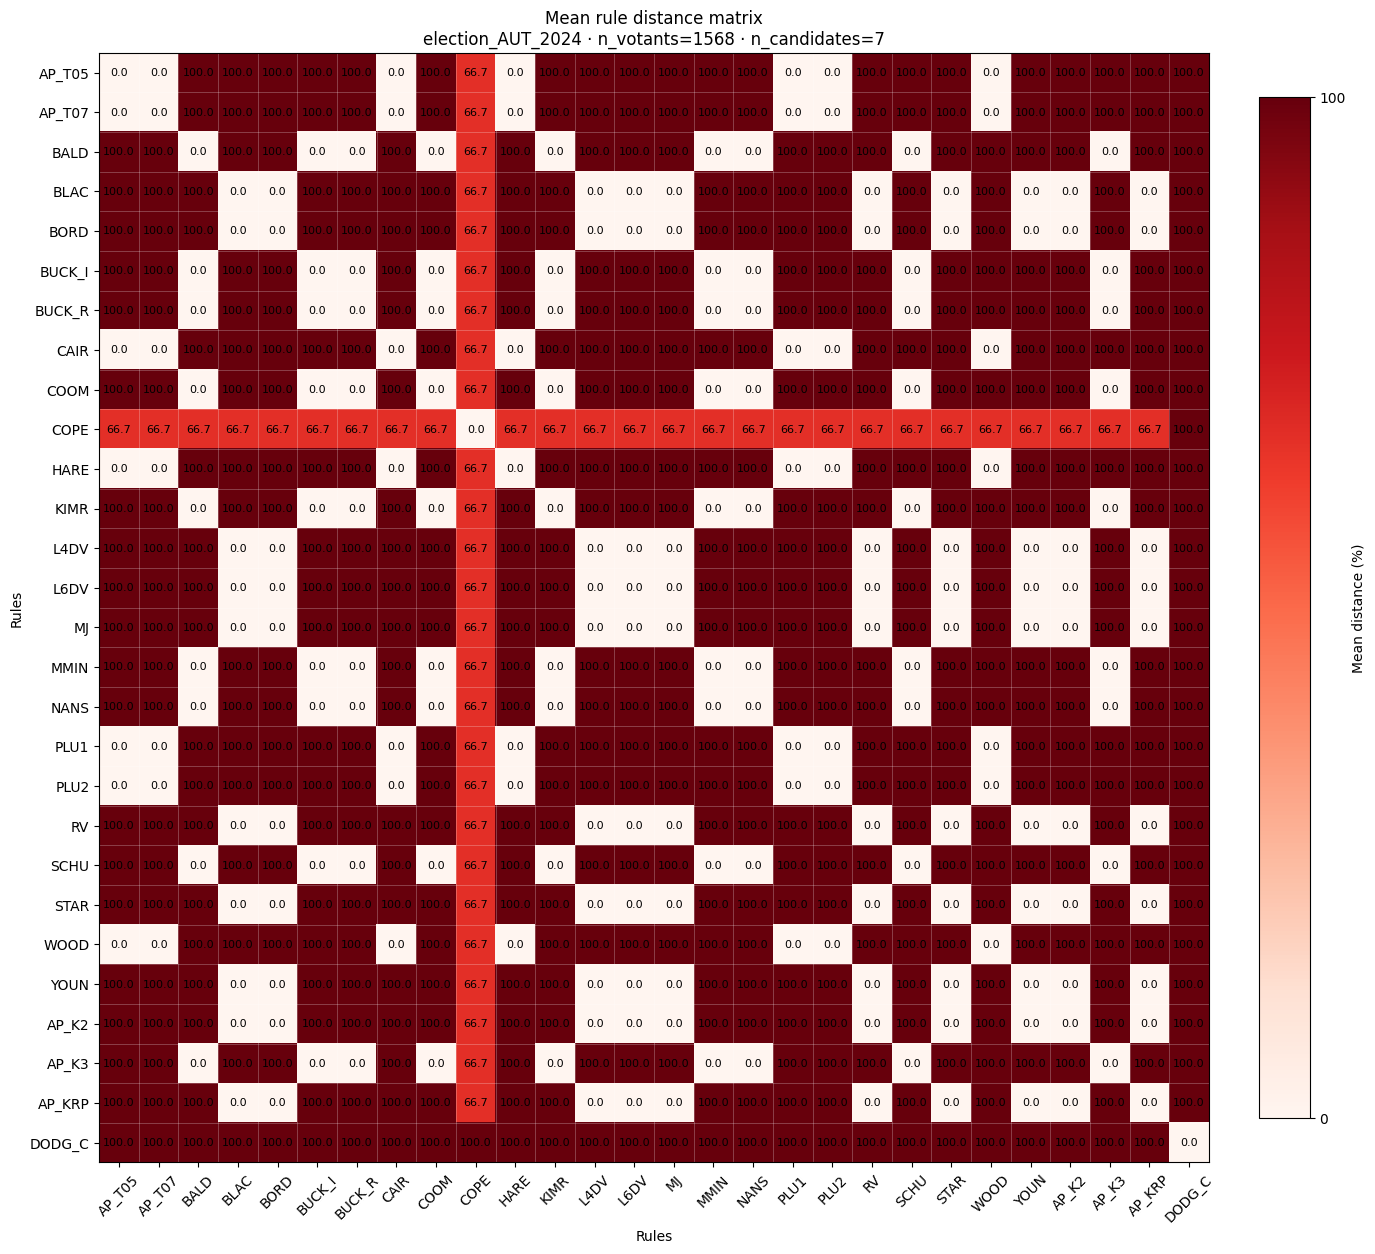

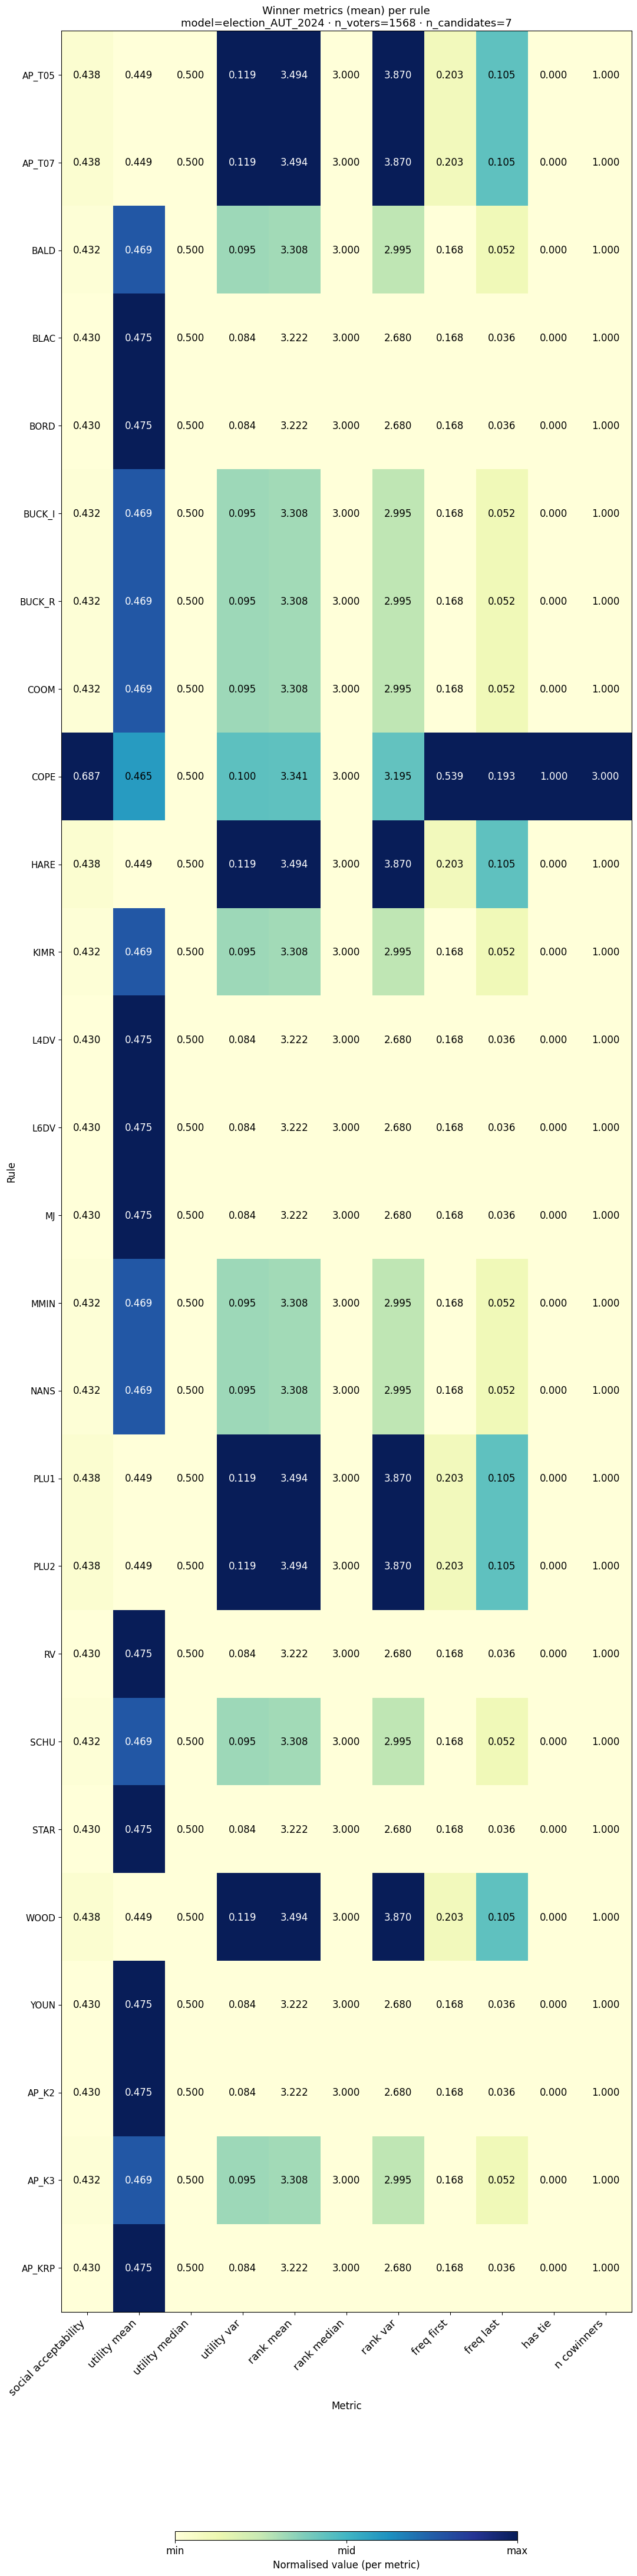

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


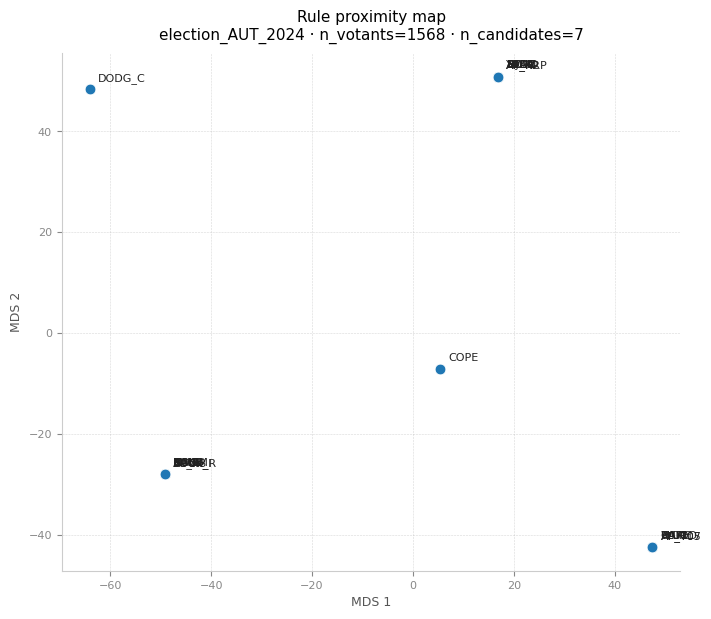

Condorcet-consistent rules kept : ['BALD', 'BLAC', 'COPE', 'SCHU', 'MMIN', 'NANS', 'YOUN', 'DODG_C', 'CAIR', 'WOOD', 'HARE']


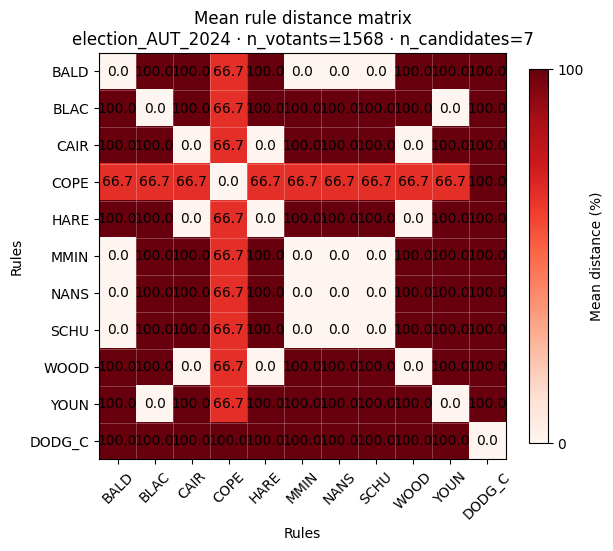

<Axes: title={'center': 'Mean rule distance matrix\nelection_AUT_2024 · n_votants=1568 · n_candidates=7'}, xlabel='Rules', ylabel='Rules'>

In [22]:
fin = total_filtered.filter(gen_model="election_AUT_2024")

fin.plot_mean_distance_matrix()

fin.plot_metrics_rules_matrix()
fin.plot_rules_2d()

CONDORCET_CONSISTENT_RULES = [
    "BALD",
    "BLAC",
    "COPE",
    "SCHU",
    "MMIN",
    "NANS",
    "YOUN",
    "DODG_C",
    "CAIR",
    "WOOD",
    "HARE",
]

# Keep only rules present in the current filtered set
cc_rules = [r for r in CONDORCET_CONSISTENT_RULES if r in CONDORCET_CONSISTENT_RULES]

print(f"Condorcet-consistent rules kept : {cc_rules}")

total_cc = fin.filter_rules(cc_rules)

total_cc.plot_mean_distance_matrix(save_path=str(base_path / "aout_cc_mean_distance.png"))
# total_cc.plot_rules_2d()
# total_cc.plot_metrics_rules_matrix()

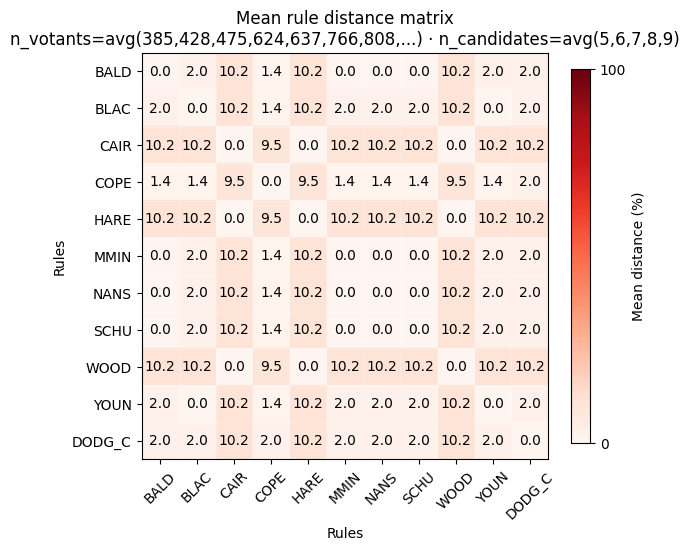

<Axes: title={'center': 'Mean rule distance matrix\nn_votants=avg(385,428,475,624,637,766,808,...) · n_candidates=avg(5,6,7,8,9)'}, xlabel='Rules', ylabel='Rules'>

In [23]:
total_cc = total_filtered.filter_rules(cc_rules)

total_cc.plot_mean_distance_matrix(save_path=str(base_path / "cc_mean_distance.png"))
# total_cc.plot_rules_2d()
# total_cc.plot_metrics_rules_matrix()

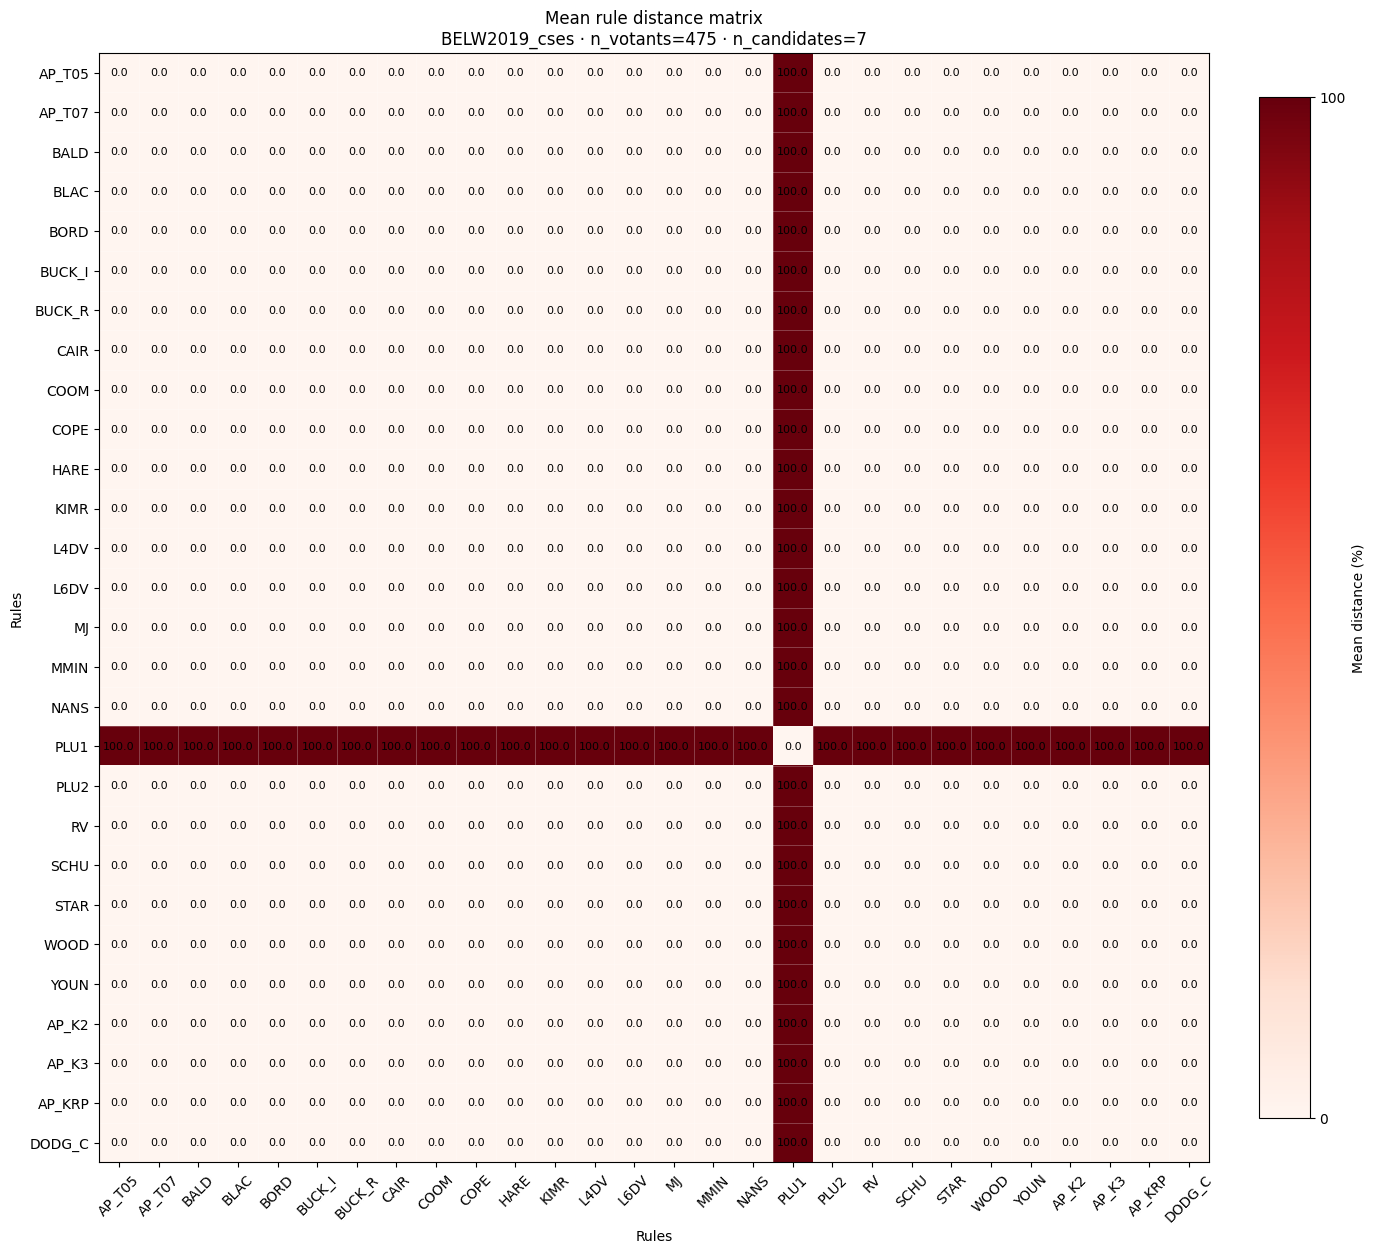

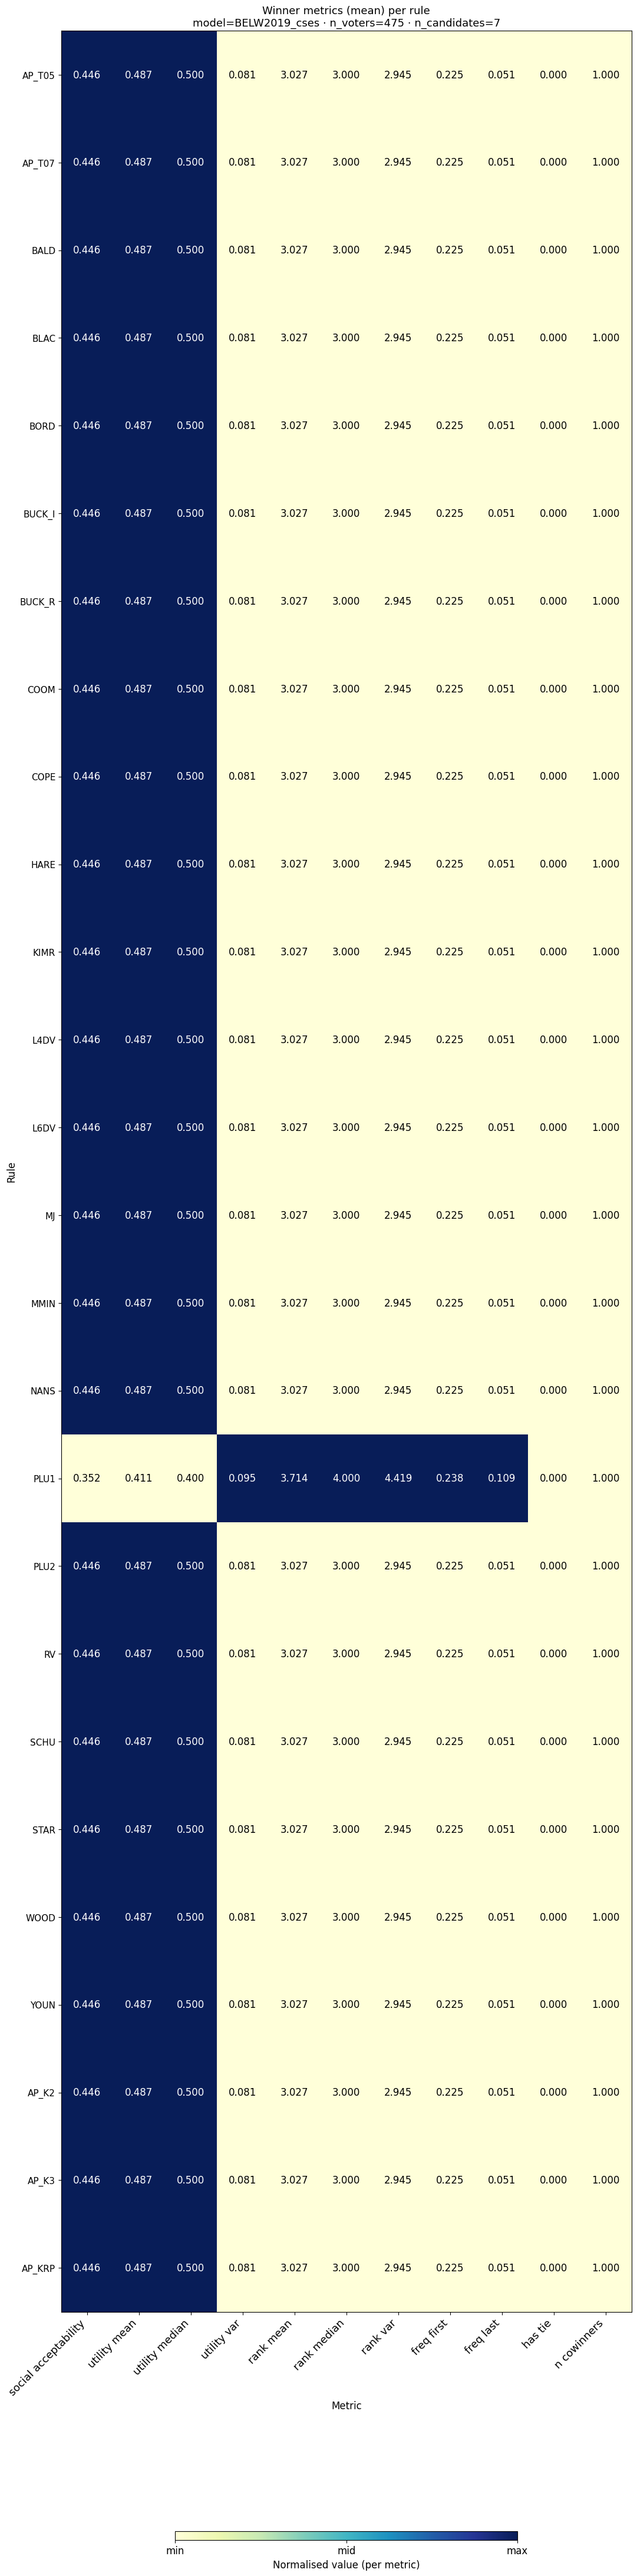

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


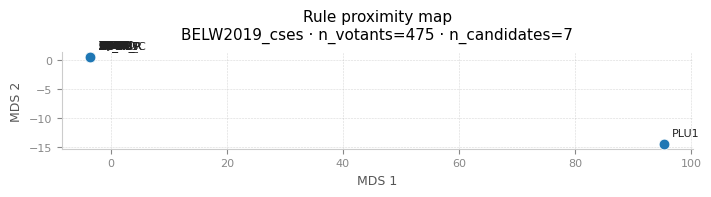

<Axes: title={'center': 'Rule proximity map\nBELW2019_cses · n_votants=475 · n_candidates=7'}, xlabel='MDS 1', ylabel='MDS 2'>

In [11]:
fin = total_filtered.filter(gen_model="BELW2019_cses")

fin.plot_mean_distance_matrix()

fin.plot_metrics_rules_matrix()
fin.plot_rules_2d()

# total_filtered.plot_metrics_rules_matrix(save_path=str(base_path / "metrics_no_APT0GE.png"))

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


<Axes: title={'center': 'Rule proximity map\nn_votants=avg(385,428,475,624,637,766,808,...) · n_candidates=avg(5,6,7,8,9)'}, xlabel='MDS 1', ylabel='MDS 2'>

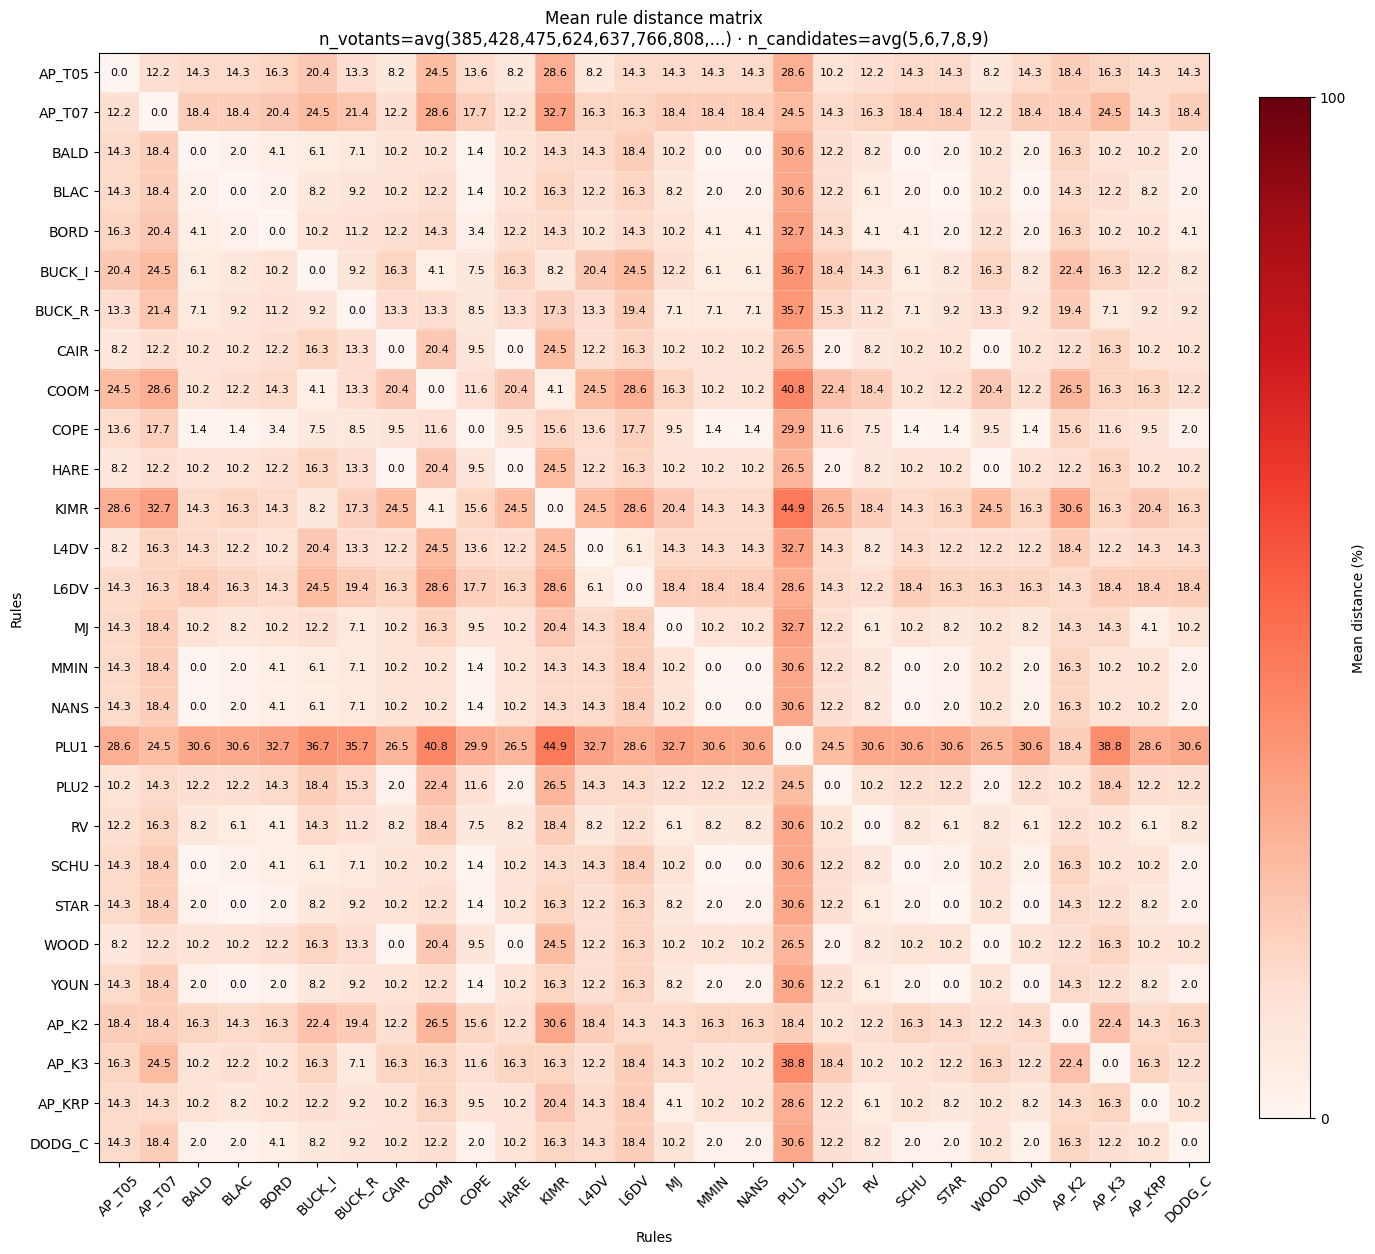

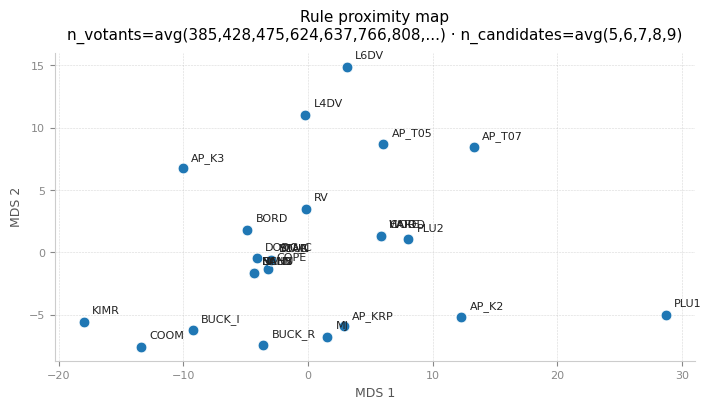

In [12]:
total_filtered.plot_mean_distance_matrix(show=False, save_path="mean_distance_no_APT0GE.png")
total_filtered.plot_rules_2d(show=False, save_path="rules_2d_no_APT0GE.png")

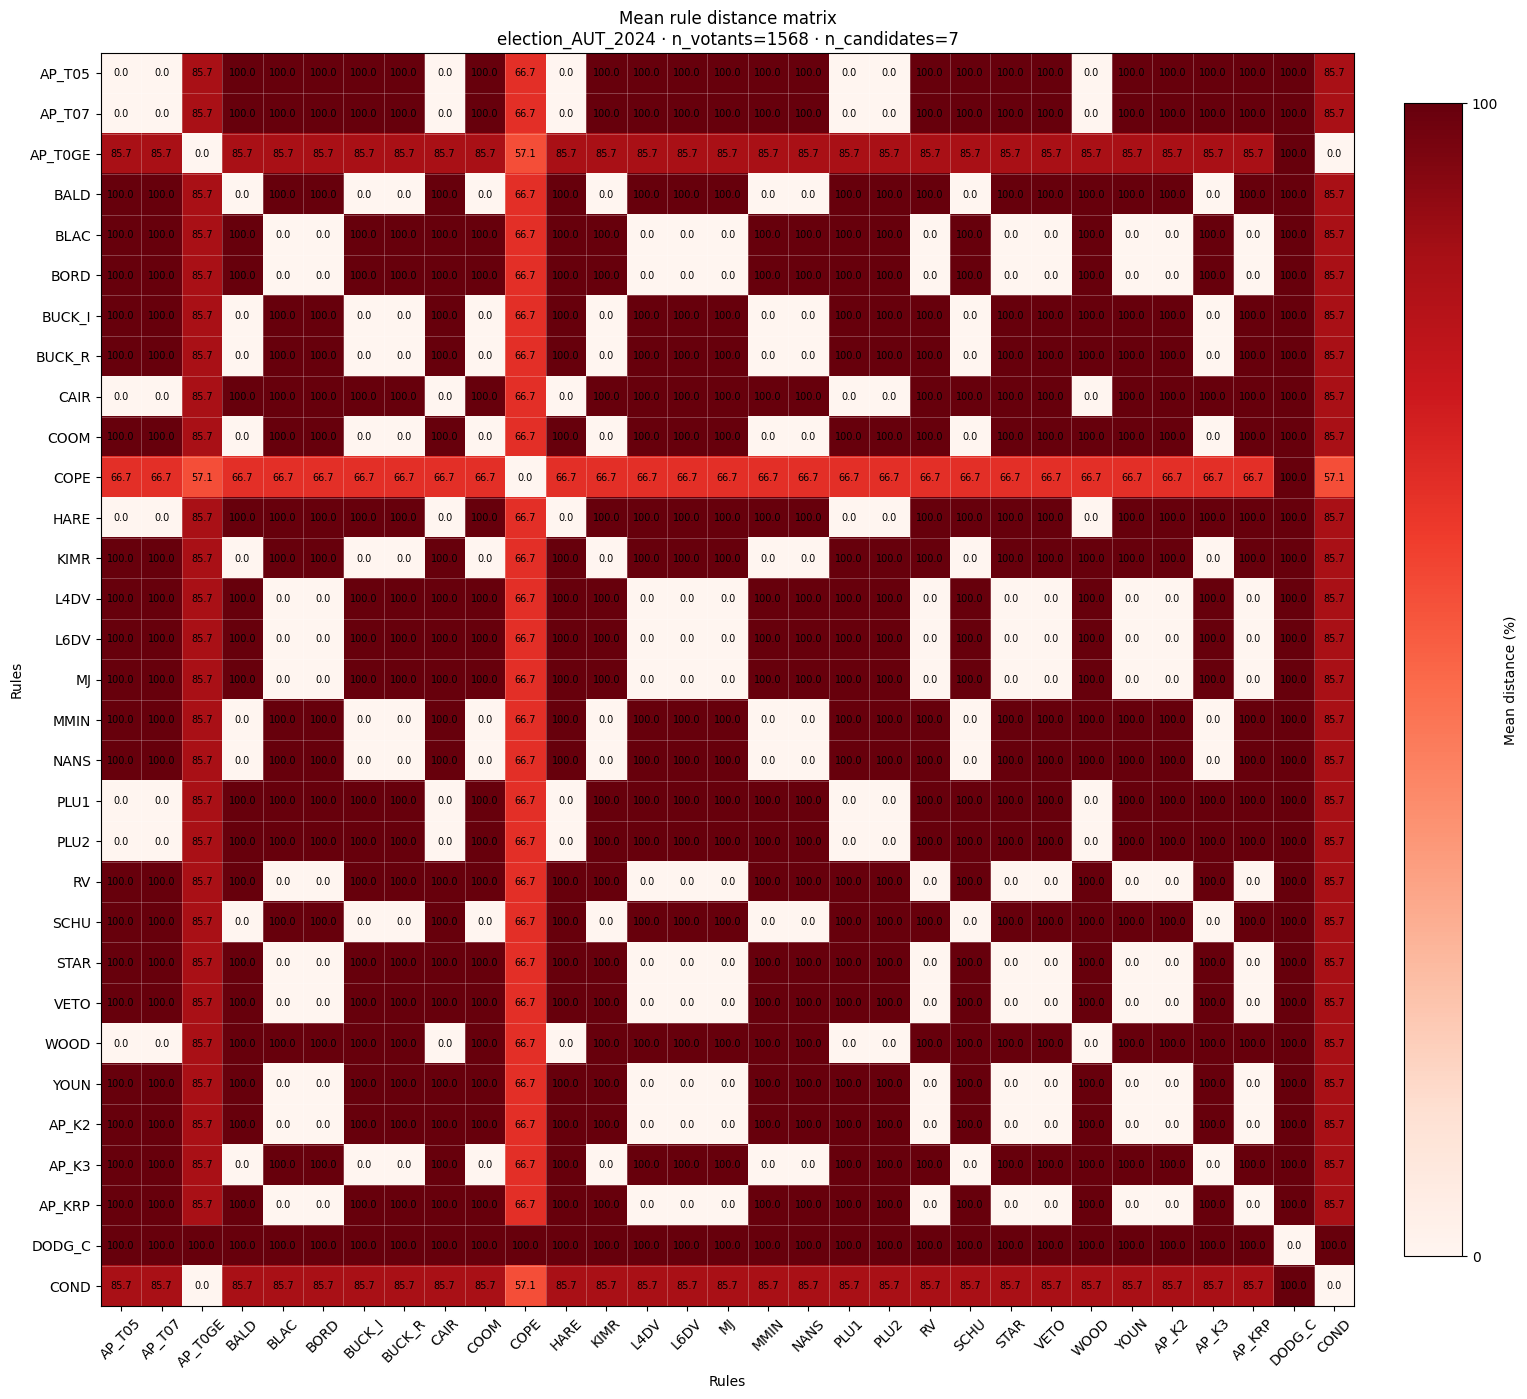

<Axes: title={'center': 'Mean rule distance matrix\nelection_AUT_2024 · n_votants=1568 · n_candidates=7'}, xlabel='Rules', ylabel='Rules'>

In [13]:
total_result.filter(gen_model="election_AUT_2024").plot_mean_distance_matrix()

In [14]:
# detail on 5 candidates

c5 = total_filtered.filter(n_candidates=5)

for v in c5.voter_counts:
    fcv = c5.filter(n_voters=v)
    name = fcv.gen_models[0]
    print(f"Name : {name}  n_candidates=5  n_voters={v}")

    m = fcv.mean_distance_matrix_frame()
    m = m.drop_duplicates()
    print(m)

Name : HUN_2018_cses  n_candidates=5  n_voters=1023
        AP_T05  AP_T07   BALD   BLAC   BORD  BUCK_I  BUCK_R   CAIR   COOM  \
AP_T05     0.0     0.0    0.0    0.0    0.0     0.0     0.0    0.0  100.0   
COOM     100.0   100.0  100.0  100.0  100.0   100.0   100.0  100.0    0.0   

         COPE  ...   PLU2     RV   SCHU   STAR   WOOD   YOUN  AP_K2  AP_K3  \
AP_T05    0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0   
COOM    100.0  ...  100.0  100.0  100.0  100.0  100.0  100.0  100.0    0.0   

        AP_KRP  DODG_C  
AP_T05     0.0     0.0  
COOM     100.0   100.0  

[2 rows x 28 columns]
Name : TWN_2016_cses  n_candidates=5  n_voters=1210
        AP_T05  AP_T07  BALD  BLAC  BORD  BUCK_I  BUCK_R  CAIR  COOM  COPE  \
AP_T05     0.0     0.0   0.0   0.0   0.0     0.0     0.0   0.0   0.0   0.0   

        ...  PLU2   RV  SCHU  STAR  WOOD  YOUN  AP_K2  AP_K3  AP_KRP  DODG_C  
AP_T05  ...   0.0  0.0   0.0   0.0   0.0   0.0    0.0    0.0     0.0     0.0  

[1 rows x 28 co